# **EXPLORING JOB DISSATISFACTION IN THE UK USING REDDIT DATA (2021 Dataset)**

## **AN NLP-BASED THEMATIC AND SENTIMENT ANALYSIS**


### **Student Name**: Awopetu Rasheed Oluwadamilare

### **Student Number**: 202432121

### **Library Installation**

In [1]:
pip install praw pandas tqdm python-dotenv emoji vaderSentiment textblob wordcloud pyLDAvis gensim bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.5 MB/s eta 0:00:00


In [2]:
pip install spacy

In [3]:
pip install tf-keras

### **Import the necessary libraries**

In [25]:
import pandas as pd
import os, time, json
import praw
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import re, emoji, nltk, spacy
import torch
import nltk
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from gensim.corpora.dictionary import Dictionary
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap.umap_ import UMAP
from hdbscan import HDBSCAN
from dotenv import load_dotenv
from datetime import datetime, timedelta
from tqdm import tqdm
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from nltk.corpus import stopwords
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
from gensim.models.ldamodel import LdaModel
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

### **Loading Dataset & Data Collection**

##### After filtering the eye.eu Reddit archive for 2021, the result is a cleaned dataset where the posts and comments are separated into two different files.

In [ ]:
Dataframe_Post = pd.read_csv('subreddit_2021_post.csv')

In [ ]:
print("Total Number of Post and row is ", Dataframe_Post.shape)

Total Number of Post and row is  (589, 6)


In [ ]:
Dataframe_Comment = pd.read_csv('subreddit_2021_comment.csv')

In [ ]:
print("Total Number of Post and row is ", Dataframe_Comment.shape)

Total Number of Post and row is  (21336, 6)


### **CSV File combined**

###### Let **combined the 2 datset** together so we can be able to work with a single dataset

In [ ]:
dataset = pd.concat([Dataframe_Post, Dataframe_Comment], ignore_index=True)
print("Combined dataset shape:", dataset.shape)
dataset.head()

Combined dataset shape: (21925, 6)


,id,created_utc,year,subreddit,sentiment,selftext
0,kx4b32,1610625565,2021,antiwork,dissatisfaction,I want to preface this by saying I have been a...
1,lwp19v,1614760350,2021,antiwork,dissatisfaction,I hate being a manager. I feel like I've reall...
2,lyf62f,1614960550,2021,antiwork,dissatisfaction,I work in a company that I can't really name h...
3,m32djq,1615501254,2021,antiwork,dissatisfaction,For the past 2 years I’ve been running a compa...
4,m74e06,1615998760,2021,antiwork,dissatisfaction,I hate my job. I hate the soul-sucking work we...


##### Saving the combined dataset so we can use it in our sentiment analysis

In [ ]:
dataset.to_csv('2021_JOB_Dissatisfaction.csv', index=False)

#### **Loading Saved Dataset**

###### We’re importing our dataset from a CSV file and taking a quick look at the top few records to get familiar with the structure of the data before we dive into analysis.

In [ ]:
Dataset = pd.read_csv('2021_JOB_Dissatisfaction.csv')
Dataset.head()

,id,created_utc,year,subreddit,sentiment,selftext
0,kx4b32,1610625565,2021,antiwork,dissatisfaction,I want to preface this by saying I have been a...
1,lwp19v,1614760350,2021,antiwork,dissatisfaction,I hate being a manager. I feel like I've reall...
2,lyf62f,1614960550,2021,antiwork,dissatisfaction,I work in a company that I can't really name h...
3,m32djq,1615501254,2021,antiwork,dissatisfaction,For the past 2 years I’ve been running a compa...
4,m74e06,1615998760,2021,antiwork,dissatisfaction,I hate my job. I hate the soul-sucking work we...


### **Data Exploration**

###### Let's examining and understanding our dataset before doing any analysis or modeling.

##### **Displaying basic info of the Dataset**

In [ ]:
print(Dataset.shape)

(21925, 6)


In [ ]:
print(Dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           21925 non-null  object
 1   created_utc  21925 non-null  int64 
 2   year         21925 non-null  int64 
 3   subreddit    21925 non-null  object
 4   sentiment    21925 non-null  object
 5   selftext     21925 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.0+ MB
None


##### **Checking Missing Value**

In [ ]:
print(Dataset.isnull().sum())

id             0
created_utc    0
year           0
subreddit      0
sentiment      0
selftext       0
dtype: int64


##### **Checking for Duplicates**

In [ ]:
print(Dataset.duplicated(subset=['selftext']).sum())

631


###### We discovered that we have 631 Duplicates in our Dataset. We are going to remove all this duplicates during the data cleaning

###### Let check our `label` field that we go from the **Reddit API**  

In [ ]:
Dataset = Dataset.rename(columns={"sentiment": "label"})

In [ ]:
print(Dataset['label'].value_counts())

label
dissatisfaction    19649
satisfaction        2276
Name: count, dtype: int64


###### We clearly discovered that we have 19,649 data that is related to dissatisfaction and 2,276 data that relate to satisfaction.

/tmp/ipython-input-7856422.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=Dataset, palette=["red", "green"])


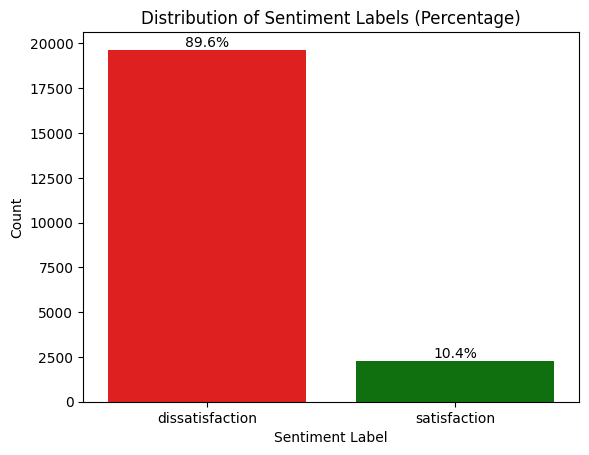

In [ ]:
ax = sns.countplot(x='label', data=Dataset, palette=["red", "green"])

total = len(Dataset)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.title('Distribution of Sentiment Labels (Percentage)')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()

##### Let explore data based on Subreddit

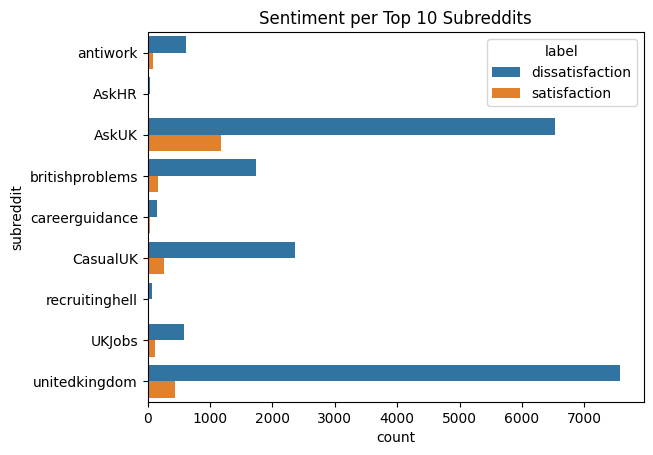

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(11).index
sns.countplot(y='subreddit', hue='label', data=Dataset[Dataset['subreddit'].isin(top_subs)])
plt.title('Sentiment per Top 10 Subreddits')
plt.show()

###### Let’s find the top subreddits, filter our dataset to include only them, and see how their sentiments compare

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(11).index
top_data = Dataset[Dataset['subreddit'].isin(top_subs)]
sentiment_table = pd.crosstab(top_data['subreddit'], top_data['label'])
display(sentiment_table)

label,dissatisfaction,satisfaction
subreddit,,
AskHR,35,6
AskUK,6532,1170
CasualUK,2360,257
UKJobs,573,112
antiwork,620,88
britishproblems,1739,163
careerguidance,143,43
recruitinghell,72,2
unitedkingdom,7575,435


###### Let’s find the top subreddits, filter our dataset to include only them, and see how their sentiments compare using the percentage

In [ ]:
top_subs = Dataset['subreddit'].value_counts().head(10).index
top_data = Dataset[Dataset['subreddit'].isin(top_subs)]
sentiment_percent = pd.crosstab(top_data['subreddit'], top_data['label'], normalize='index') * 100
sentiment_percent = sentiment_percent.round(1)
display(sentiment_percent)

label,dissatisfaction,satisfaction
subreddit,,
AskHR,85.4,14.6
AskUK,84.8,15.2
CasualUK,90.2,9.8
UKJobs,83.6,16.4
antiwork,87.6,12.4
britishproblems,91.4,8.6
careerguidance,76.9,23.1
recruitinghell,97.3,2.7
unitedkingdom,94.6,5.4


###### Let’s create word clouds to visualize what people talk about most comparing positive (satisfaction) and negative (dissatisfaction) words side by side

In [ ]:
Dataset = Dataset.rename(columns={"selftext": "text_raw"})

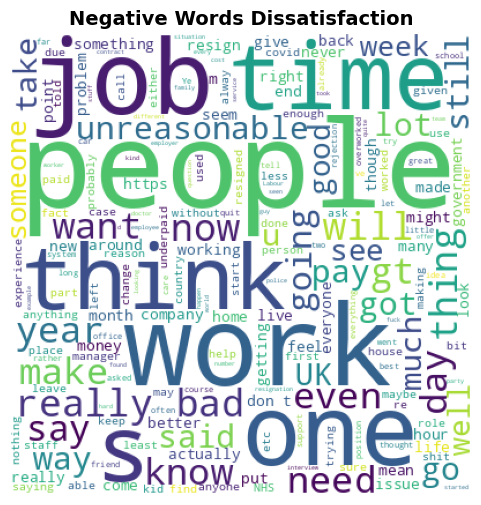

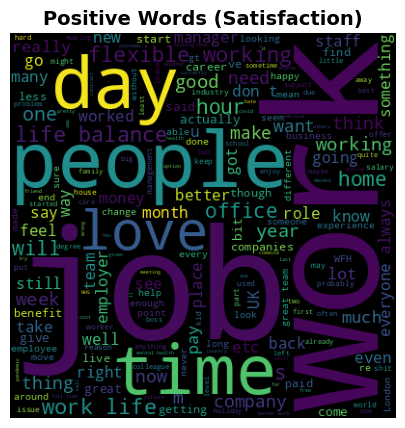

In [ ]:
pos_text = ' '.join(Dataset[Dataset['label']=='satisfaction']['text_raw'])
neg_text = ' '.join(Dataset.loc[Dataset['label'] == 'dissatisfaction', 'text_raw'].dropna().astype(str))

plt.figure(figsize=(6, 6))
plt.imshow(WordCloud(width=400, height=400, background_color='white').generate(neg_text))
plt.title('Negative Words Dissatisfaction', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(WordCloud(width=400, height=400).generate(pos_text))
plt.title('Positive Words (Satisfaction)', fontsize=14, fontweight='bold')
plt.axis('off')

plt.show()

### **Data Cleaning**

###### Removing the column with [Removed] and [Deleted] columns

In [ ]:
print("Row before cleaning:", len(Dataset))

Dataset = Dataset[~Dataset['text_raw'].isin(['[deleted]', '[removed]'])]
Dataset = Dataset[~Dataset['text_raw'].str.lower().str.strip().isin(['[deleted]', '[removed]'])]
Dataset = Dataset.reset_index(drop=True)

print("Remaining rows after cleaning:", len(Dataset))


Row before cleaning: 21925
Remaining rows after cleaning: 21925


###### Drop rows with missing or empty text

In [ ]:
print("Row before dropping missing/empty text:", len(Dataset))

Dataset = Dataset[Dataset['text_raw'].notnull() & (Dataset['text_raw'].str.strip() != '')]

print("Row After dropping missing/empty text:", len(Dataset))

Row before dropping missing/empty text: 21925
Row After dropping missing/empty text: 21925


#### **Removing Duplicates**

In [ ]:
print("Row before removing duplicate:", len(Dataset))

Dataset = Dataset.drop_duplicates(subset=['text_raw'], keep='first')

print("Row After removing duplicate:", len(Dataset))

Row before removing duplicate: 21294
Row After removing duplicate: 21294


###### Now, let’s clean our **text_raw** data by converting everything to lowercase, removing URLs and emojis, filtering out stopwords, and applying lemmatization to make the text neat and consistent!


In [ ]:
nltk.download("stopwords")
EN_STOP = set(stopwords.words("english"))
nlp = spacy.load("en_core_web_sm", exclude=["ner","parser","textcat"])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # lowercase
    text = emoji.replace_emoji(text, replace=" ")   # remove emojis
    text = re.sub(r"http\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"[^\w\s']", " ", text)          # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

def lemmatize(text):
    doc = nlp(text)
    return " ".join(
        tok.lemma_ for tok in doc
        if tok.lemma_ not in EN_STOP and tok.is_alpha
    )

Dataset["text_clean"] = Dataset["text_raw"].apply(clean_text)
Dataset["text_lemma"] = Dataset["text_clean"].apply(lemmatize)

print("Cleaned & lemmatized posts and comments")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Cleaned & lemmatized posts and comments


###### We have successfully cleaned our dataset. Let **Preview** it and move on to the **Sentiment analysis**

In [ ]:
display(Dataset.head())

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma
0,kx4b32,1610625565,2021,antiwork,dissatisfaction,I want to preface this by saying I have been a...,i want to preface this by saying i have been a...,I want preface say I anti work long time know ...
1,lwp19v,1614760350,2021,antiwork,dissatisfaction,I hate being a manager. I feel like I've reall...,i hate being a manager i feel like i've really...,I hate manager I feel like I really pull back ...
2,lyf62f,1614960550,2021,antiwork,dissatisfaction,I work in a company that I can't really name h...,i work in a company that i can't really name h...,I work company I really name suffice say huge ...
3,m32djq,1615501254,2021,antiwork,dissatisfaction,For the past 2 years I’ve been running a compa...,for the past 2 years i ve been running a compa...,past year I run company boss without acknowled...
4,m74e06,1615998760,2021,antiwork,dissatisfaction,I hate my job. I hate the soul-sucking work we...,i hate my job i hate the soul sucking work we ...,I hate job I hate soul suck work penny I hate ...


In [ ]:
Dataset.to_csv('2021_JOB_Dissatisfaction_Cleaned.csv', index=False)

In [ ]:
Dataset = pd.read_csv('2021_JOB_Dissatisfaction_Cleaned.csv')

### **Sentiment Analysis**

##### Sentiment analysis is a natural language processing technique that identifies and classifies emotions or opinions in text as positive, negative, or neutral. It helps organizations understand customer feedback, social media posts, or reviews. Using machine learning, it automates the process of interpreting human emotions for better decision-making and communication.


### **Reddit Label**

###### Let’s rename our sentiment labels for clarity — changing *satisfaction* to **Positive** and *dissatisfaction* to **Negative**, then count how many posts fall into each category

In [ ]:
Dataset['label'] = Dataset['label'].replace('dissatisfaction', 'Negative')
Dataset['label'] = Dataset['label'].replace('satisfaction', 'Positive')
Reddit_Label = Dataset["label"].value_counts().sort_index()
print(Reddit_Label)

label
Negative    19098
Positive     2196
Name: count, dtype: int64


###### Let’s visualize the number of posts for each sentiment label with a simple bar chart to see how our data is distributed

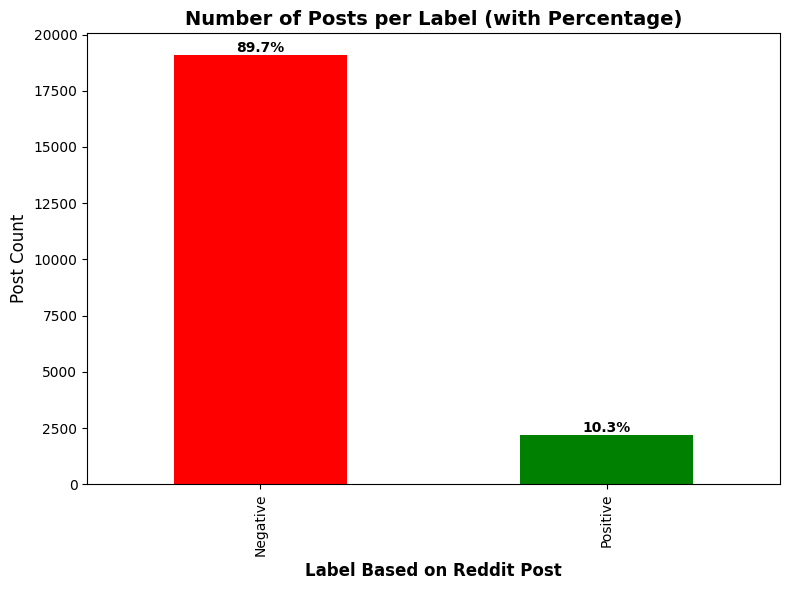

In [ ]:
plt.figure(figsize=(8, 6))
ax = Reddit_Label.plot(kind="bar", color=['red', 'green'])
total = Reddit_Label.sum()
for i, value in enumerate(Reddit_Label):
    percent = 100 * value / total
    ax.text(i, value + 0.5, f'{percent:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title("Number of Posts per Label (with Percentage)", fontsize=14, fontweight='bold')
plt.xlabel("Label Based on Reddit Post", fontsize=12, fontweight="bold")
plt.ylabel("Post Count", fontsize=12)
plt.tight_layout()
plt.show()

#### **Rule Based Using Vader**

###### VADER (Valence Aware Dictionary and sEntiment Reasoner) is a rule-based sentiment analysis tool designed for social media text. It uses a pre-built lexicon and considers word intensity, punctuation, capitalization, and emojis to determine sentiment scores positive, negative, neutral, and compound. Making it accurate for short, informal, and expressive online language.


###### Make a VADER analyzer to check how positive or negative text is

In [ ]:
analyzer = SentimentIntensityAnalyzer()

###### Let’s use the **VADER** sentiment analyzer to score each post’s emotional tone, then classify it as **Positive**, **Negative**, or **Neutral** based on the compound sentiment score.


In [ ]:
Dataset['compound'] = Dataset['text_lemma'].fillna('').apply(lambda x: analyzer.polarity_scores(x)['compound'])

In [ ]:
display(Dataset.head())

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma,compound
0,kx4b32,1610625565,2021,antiwork,Negative,I want to preface this by saying I have been a...,i want to preface this by saying i have been a...,I want preface say I anti work long time know ...,0.9778
1,lwp19v,1614760350,2021,antiwork,Negative,I hate being a manager. I feel like I've reall...,i hate being a manager i feel like i've really...,I hate manager I feel like I really pull back ...,-0.8852
2,lyf62f,1614960550,2021,antiwork,Negative,I work in a company that I can't really name h...,i work in a company that i can't really name h...,I work company I really name suffice say huge ...,0.9229
3,m32djq,1615501254,2021,antiwork,Negative,For the past 2 years I’ve been running a compa...,for the past 2 years i ve been running a compa...,past year I run company boss without acknowled...,0.8261
4,m74e06,1615998760,2021,antiwork,Negative,I hate my job. I hate the soul-sucking work we...,i hate my job i hate the soul sucking work we ...,I hate job I hate soul suck work penny I hate ...,-0.9972


###### We have a new field called compound which was gotten from Vader. Let use the compound score to group their sentiment. According to Vader documentation. positive sentiment: compound score >= 0.05, neutral sentiment: (compound score > -0.05) and (compound score < 0.05), negative sentiment: compound score <= -0.05  

In [ ]:
Dataset['vader_sentiment'] = Dataset['vader_sentiment'] = Dataset['compound'].apply(lambda c: ('Positive' if c >= 0.05 else 'Negative' if c <= -0.05 else 'Neutral'))

###### Now we have sucessfully added the compound score and also a new column called vader sentiment which categorize them into Positive, Negative and Neutral

###### Let plot a bar chart showing how many posts are **Positive**, **Neutral**, or **Negative** according to VADER

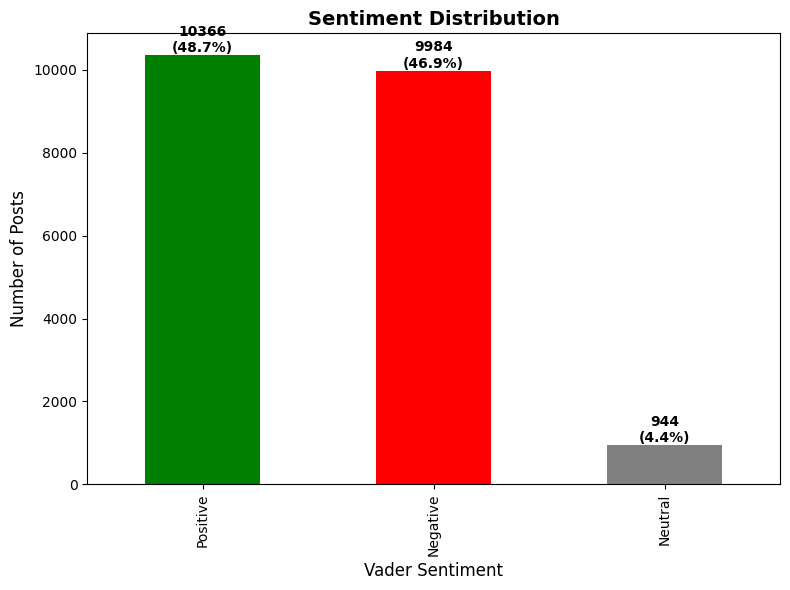

In [ ]:
sentiment_counts_vader = Dataset['vader_sentiment'].value_counts()
total = sentiment_counts_vader.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts_vader.plot(kind='bar', color=['green', 'red', 'gray'])
for i, value in enumerate(sentiment_counts_vader):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Vader Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

###### let plot an histogram to show how the VADER compound scores are spread across all reviews

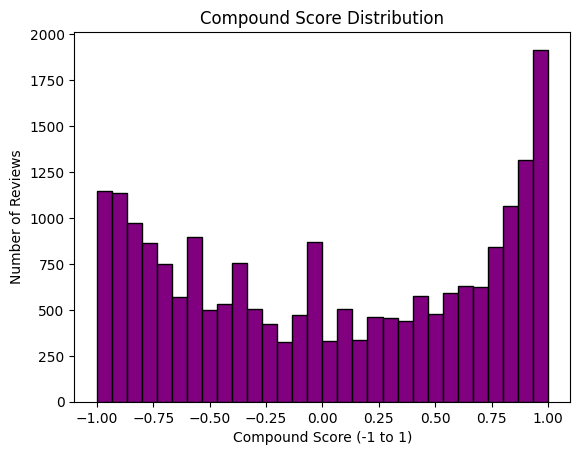

In [ ]:
plt.hist(Dataset['compound'], bins=30, color='purple', edgecolor='black')
plt.title('Compound Score Distribution')
plt.xlabel('Compound Score (-1 to 1)')
plt.ylabel('Number of Reviews')
plt.show()

###### Let create a word cloud of the most common words from positive posts

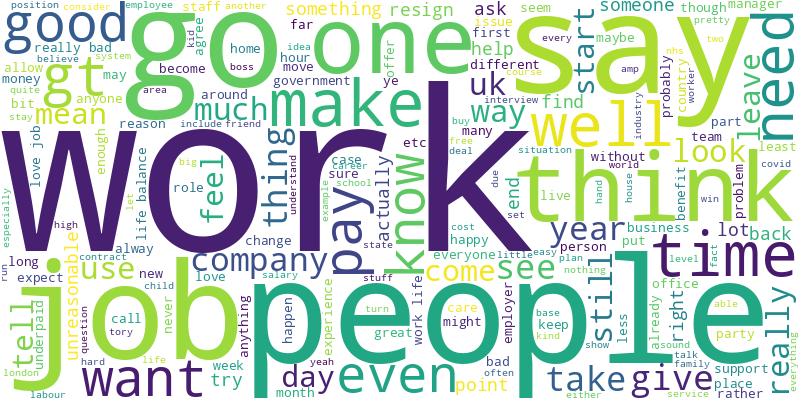

In [ ]:
pos_text = " ".join(Dataset[Dataset['vader_sentiment'] == 'Positive']['text_lemma'])
WordCloud(width=800, height=400, background_color='white').generate(pos_text).to_image()

WordCloud for the Negative word as well

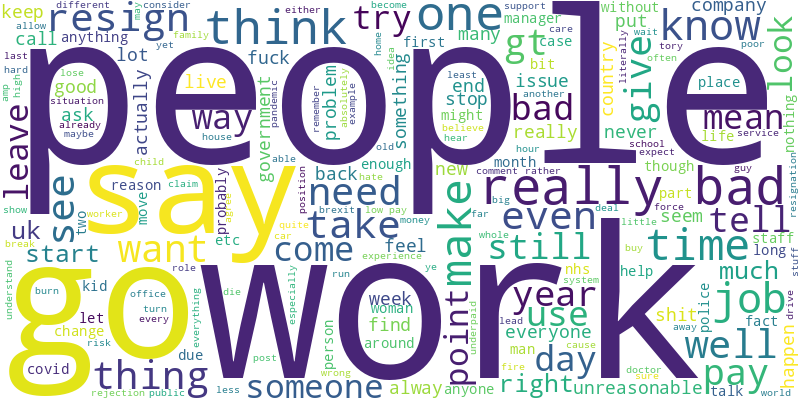

In [ ]:
pos_text = " ".join(Dataset[Dataset['vader_sentiment'] == 'Negative']['text_lemma'])
WordCloud(width=800, height=400, background_color='white').generate(pos_text).to_image()

###### Let print the most positive and most negative reviews based on the highest and lowest VADER compound scores

In [ ]:
print("Most Positive Review:")
print(Dataset.loc[Dataset['compound'].idxmax(), 'text_lemma'])

print("\nMost Negative Review:")
print(Dataset.loc[Dataset['compound'].idxmin(), 'text_lemma'])

Most Positive Review:
disclaimer I want thank everyone gild reply suggestion I time reply everyone I read everything I sure much big thread I already type vanish I think I limit I try keep update I expect thread top much long likely vanish soon need anything save yes hard suck depress something want see virus go everyone know deal many think exception one however stay home hard maybe I help least one two people incentive I try give link thing help cure boredom support need might obvious might even internet course money big issue I try give suggestion streaming demand thing netflix et al forget subscribe free first month go thing list worried put payment detail forget cancel month later worry sign immediately cancel still get free month people smart tv buy cheap amazon fire tv stick roku box fire stick go low often drop I pick roku device amazon fast snappy currently go version little difference device nowtv also roku power device subscription base stream site offer week free first time

#### **Rule Based Using TextBlob**

###### TextBlob is a Python library for processing textual data. It provides simple APIs for tasks like sentiment analysis, part-of-speech tagging, and noun phrase extraction. Using pre-trained models, TextBlob assigns polarity (positive or negative) and subjectivity scores, making it beginner-friendly for quickly analyzing text and building natural language processing applications.


###### Let's download TextBlob's required NLTK corpora (needed for sentiment analysis, translation, etc.)

In [ ]:
!python3 -m textblob.download_corpora

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


###### Let calculate TextBlob sentiment scores for each text (polarity and subjectivity) and also display the first few rows to check the new columns

In [ ]:
Dataset['polarity'] = Dataset['text_lemma'].fillna('').apply(lambda x: TextBlob(x).sentiment.polarity)
Dataset['subjectivity'] = Dataset['text_lemma'].fillna('').apply(lambda x: TextBlob(x).sentiment.subjectivity)

display(Dataset.head())

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma,compound,vader_sentiment,polarity,subjectivity
0,kx4b32,1610625565,2021,antiwork,Negative,I want to preface this by saying I have been a...,i want to preface this by saying i have been a...,I want preface say I anti work long time know ...,0.9778,Positive,0.159743,0.545853
1,lwp19v,1614760350,2021,antiwork,Negative,I hate being a manager. I feel like I've reall...,i hate being a manager i feel like i've really...,I hate manager I feel like I really pull back ...,-0.8852,Negative,-0.052921,0.507481
2,lyf62f,1614960550,2021,antiwork,Negative,I work in a company that I can't really name h...,i work in a company that i can't really name h...,I work company I really name suffice say huge ...,0.9229,Positive,0.023620,0.517177
3,m32djq,1615501254,2021,antiwork,Negative,For the past 2 years I’ve been running a compa...,for the past 2 years i ve been running a compa...,past year I run company boss without acknowled...,0.8261,Positive,0.152056,0.388853
4,m74e06,1615998760,2021,antiwork,Negative,I hate my job. I hate the soul-sucking work we...,i hate my job i hate the soul sucking work we ...,I hate job I hate soul suck work penny I hate ...,-0.9972,Negative,-0.196134,0.544557


###### Let's define a function to label TextBlob polarity scores as Positive, Negative, or Neutral

In [ ]:
def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

###### Apply the label_sentiment function to classify each TextBlob polarity score as Positive, Negative, or Neutral

In [ ]:
Dataset["Blob_Sentiment"] = Dataset["polarity"].apply(label_sentiment)

###### Let's count how many posts fall into each TextBlob sentiment category (Positive, Negative, Neutral)

In [ ]:
sentiment_counts_blob = Dataset["Blob_Sentiment"].value_counts()

In [ ]:
print(sentiment_counts_blob)

Blob_Sentiment
Positive    11497
Negative     8378
Neutral      1419
Name: count, dtype: int64


###### Let plot a bar chart showing how many reviews are Positive, Neutral, or Negative based on TextBlob sentiment

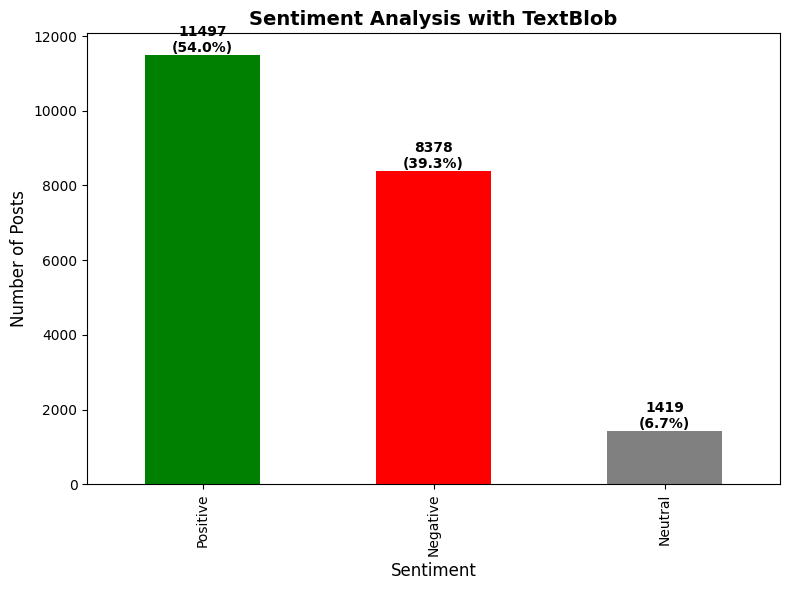

In [ ]:
sentiment_counts = sentiment_counts_blob
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Analysis with TextBlob', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

#### **Using Transformer**

##### I loaded a Reddit-trained sentiment model and set up a pipeline to score each text in my dataset. Then I wrote a function that runs the sentiment analysis in batches, picks the highest-scoring label, and adds the sentiment results back into the dataset. Finally, I printed a small preview to check that everything worked.

In [ ]:
MODEL_NAME = "spacesedan/reddit-sentiment-analysis-longformer"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

clf = pipeline(
    task="sentiment-analysis",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    truncation=True,
    max_length=128,
)

def _batch_hf_sentiment(text_series: pd.Series, batch_size: int = 64) -> pd.DataFrame:
    """
    Run HF sentiment in batches over a pandas Series of text and return
    a DataFrame with columns: neg, neu, pos, sentiment (string label).
    """
    text_series = text_series.fillna("").astype(str)

    outputs = clf(list(text_series), batch_size=batch_size)

    rows = []
    for scores in outputs:
        label_to_score = {d["label"].lower(): float(d["score"]) for d in scores}
        top_label = max(label_to_score, key=label_to_score.get)

        rows.append({
            "neg": label_to_score.get("negative"),
            "neu": label_to_score.get("neutral"),
            "pos": label_to_score.get("positive"),
            "sentiment": top_label
        })

    return pd.DataFrame(rows, index=text_series.index)

Dataset_scores = _batch_hf_sentiment(Dataset["text_lemma"])

Dataset = pd.concat([Dataset, Dataset_scores], axis=1)

print(Dataset[["text_lemma", "sentiment"]].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Device set to use cuda:0
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
Initializing global attention on CLS token...
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


                                          text_lemma      sentiment
0  I want preface say I anti work long time know ...        neutral
1  I hate manager I feel like I really pull back ...  very negative
2  I work company I really name suffice say huge ...  very negative
3  past year I run company boss without acknowled...        neutral
4  I hate job I hate soul suck work penny I hate ...  very negative


##### **Visualization for Transformer**

In [ ]:
display(Dataset)

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma,compound,vader_sentiment,polarity,subjectivity,Blob_Sentiment,neg,neu,pos,sentiment
0,kx4b32,1610625565,2021,antiwork,Negative,I want to preface this by saying I have been a...,i want to preface this by saying i have been a...,I want preface say I anti work long time know ...,0.9778,Positive,0.159743,0.545853,Positive,0.092485,0.357545,0.257851,neutral
1,lwp19v,1614760350,2021,antiwork,Negative,I hate being a manager. I feel like I've reall...,i hate being a manager i feel like i've really...,I hate manager I feel like I really pull back ...,-0.8852,Negative,-0.052921,0.507481,Negative,0.047666,0.022124,0.034357,very negative
2,lyf62f,1614960550,2021,antiwork,Negative,I work in a company that I can't really name h...,i work in a company that i can't really name h...,I work company I really name suffice say huge ...,0.9229,Positive,0.023620,0.517177,Positive,0.026565,0.428132,0.015284,very negative
3,m32djq,1615501254,2021,antiwork,Negative,For the past 2 years I’ve been running a compa...,for the past 2 years i ve been running a compa...,past year I run company boss without acknowled...,0.8261,Positive,0.152056,0.388853,Positive,0.041195,0.568563,0.031598,neutral
4,m74e06,1615998760,2021,antiwork,Negative,I hate my job. I hate the soul-sucking work we...,i hate my job i hate the soul sucking work we ...,I hate job I hate soul suck work penny I hate ...,-0.9972,Negative,-0.196134,0.544557,Negative,0.022063,0.012565,0.022001,very negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21289,hqqbx8q,1640986561,2021,unitedkingdom,Negative,"&gt; He said ""Any prime minister that lied to ...",gt he said any prime minister that lied to par...,gt say prime minister lie parliament would res...,-0.9081,Negative,-0.133333,0.566667,Negative,0.366255,0.033111,0.031448,negative
21290,hqqgque,1640988694,2021,unitedkingdom,Negative,A lot of the rules about proper conduct for a ...,a lot of the rules about proper conduct for a ...,lot rule proper conduct politician technically...,0.6249,Positive,0.020040,0.301984,Positive,0.014609,0.217896,0.005739,very negative
21291,hqqk1p0,1640990156,2021,unitedkingdom,Negative,His media advisor told him not to do the inter...,his media advisor told him not to do the inter...,medium advisor tell interview resign insist go...,-0.3400,Negative,0.000000,0.000000,Neutral,0.014058,0.752392,0.005369,neutral
21292,hqqm8zj,1640991162,2021,unitedkingdom,Negative,&gt;There wasn't a single pro-EU or pro-remain...,gt there wasn't a single pro eu or pro remain ...,gt single pro eu pro remain comment tweet post...,-0.7506,Negative,0.009524,0.204762,Positive,0.033317,0.426149,0.010106,neutral


###### Because the Transformer we used is 5-point sentiment classification. we need to merge Very positive with postive and very Negative with Negative and plot our chart

In [ ]:
Dataset['sentiment'] = Dataset['sentiment'].replace('negative', 'Negative')
Dataset['sentiment'] = Dataset['sentiment'].replace('positive', 'Positive')
Dataset['sentiment'] = Dataset['sentiment'].replace('neutral', 'Neutral')
Dataset['sentiment'] = Dataset['sentiment'].replace('very negative', 'Negative')
Dataset['sentiment'] = Dataset['sentiment'].replace('very positive', 'Positive')

In [ ]:
Dataset['sentiment'].value_counts()

,count
sentiment,
Neutral,9156
Negative,7675
Positive,4463


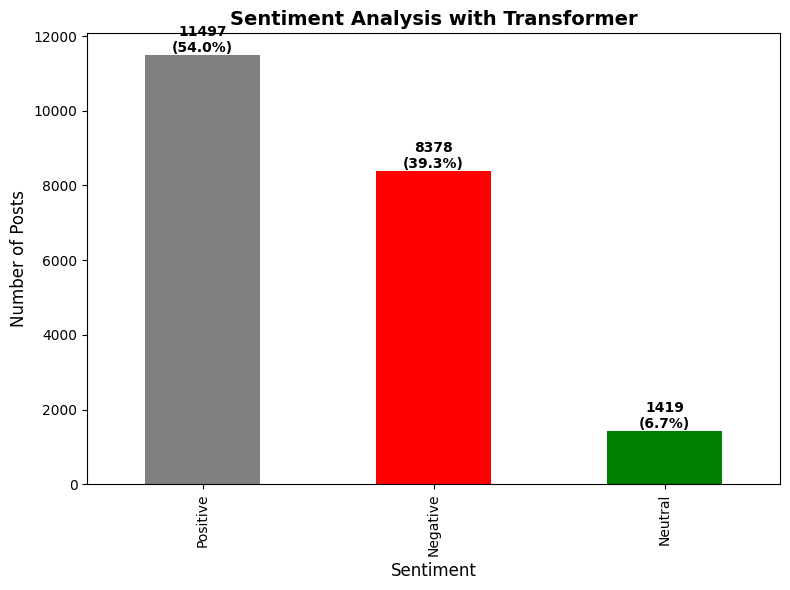

In [ ]:
sentiment_counts_transformer = Dataset['sentiment'].value_counts()
total = sentiment_counts.sum()
plt.figure(figsize=(8, 6))
ax = sentiment_counts.plot(kind='bar', color=['gray', 'red', 'green'])
for i, value in enumerate(sentiment_counts):
    percent = 100 * value / total
    ax.text(i, value + 0.5,
            f'{value}\n({percent:.1f}%)',
            ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.title('Sentiment Analysis with Transformer', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)
plt.tight_layout()
plt.show()

### **Comparison between Vader, TextBlob and Transformer**

###### VADER handles social media text and slang better, while TextBlob is simpler, offering broader NLP features but less accurate on informal language.

###### Let's Compare the number of Positive, Neutral, and Negative sentiments between TextBlob and VADER and also Combine both results into one DataFrame for easy comparison then display them

In [ ]:
textblob_counts = sentiment_counts_blob
vader_counts = sentiment_counts_vader
Transformer_counts = sentiment_counts_transformer

comparison = pd.DataFrame({
    "TextBlob": textblob_counts,
    "VADER": vader_counts,
    "Transformer(twitter-roberta-base-sentiment-latest)": Transformer_counts
})

display(comparison)

,TextBlob,VADER,Transformer(twitter-roberta-base-sentiment-latest)
Negative,8378,9984,7675
Neutral,1419,944,9156
Positive,11497,10366,4463


###### Plotting a side-by-side bar chart to compare TextBlob and VADER sentiment results.

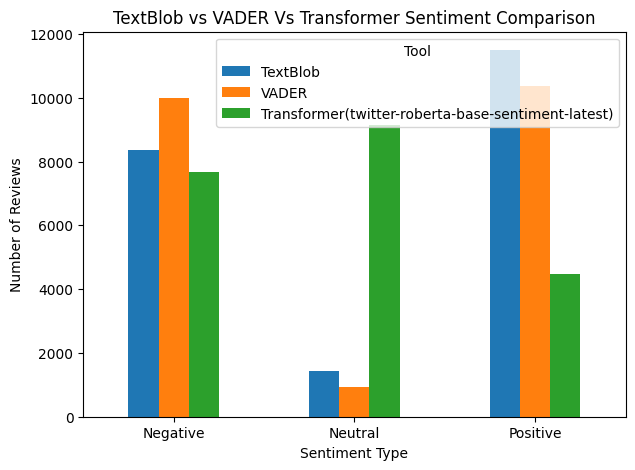

In [ ]:
comparison.plot(kind="bar", figsize=(7,5))
plt.title("TextBlob vs VADER Vs Transformer Sentiment Comparison")
plt.xlabel("Sentiment Type")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Tool")
plt.show()

#### **Model Agreement**

###### Let’s check how consistent our sentiment models are! We’ll see what percentage of samples all four models agree on and how often at least two models share the same sentiment.

In [ ]:
from collections import Counter

Dataset["all_agree"] = (
    (Dataset["vader_sentiment"] == Dataset["Blob_Sentiment"]) &
    (Dataset["vader_sentiment"] == Dataset["sentiment"])
)

all_agree_rate = Dataset['all_agree'].mean()

def majority_agreement(row):
    votes = [row['vader_sentiment'], row['Blob_Sentiment'], row['sentiment']]
    return len(set(votes)) < 3

Dataset['two_or_more_agree'] = Dataset.apply(majority_agreement, axis=1)
two_plus_agree_rate = Dataset['two_or_more_agree'].mean()

print(f"All 4 labelling models agree on {all_agree_rate:.2%} of samples")
print(f"At least two models agree on {two_plus_agree_rate:.2%} of samples")

All 4 labelling models agree on 26.18% of samples
At least two models agree on 87.64% of samples


#### **Average confidence**

###### Let’s evaluate how confident each sentiment model is in its predictions. We calculate absolute confidence scores for **VADER**, **TextBlob**, and the **Transformer model**, then compare their average confidence levels to see which model shows the strongest overall certainty.

In [ ]:
# VADER and TextBlob confidence (absolute values)
Dataset['vader_strength'] = Dataset['compound'].abs()
Dataset['textblob_strength'] = Dataset['polarity'].abs()

# Transformer confidence = highest probability among negative, neutral, positive
Dataset['transformer_strength'] = Dataset[['neg', 'neu', 'pos']].max(axis=1)

# Print average confidence for all three
print("Average VADER confidence:", Dataset['vader_strength'].mean())
print("Average TextBlob confidence:", Dataset['textblob_strength'].mean())
print("Average Transformer confidence:", Dataset['transformer_strength'].mean())

Average VADER confidence: 0.6044393162393163
Average TextBlob confidence: 0.15579025640084515
Average Transformer confidence: 0.5071641466124336


###### Let’s visualize the average confidence levels of our three sentiment models **VADER**, **TextBlob**, and **Transformer** using a clear bar chart to see which model makes predictions with the most certainty!

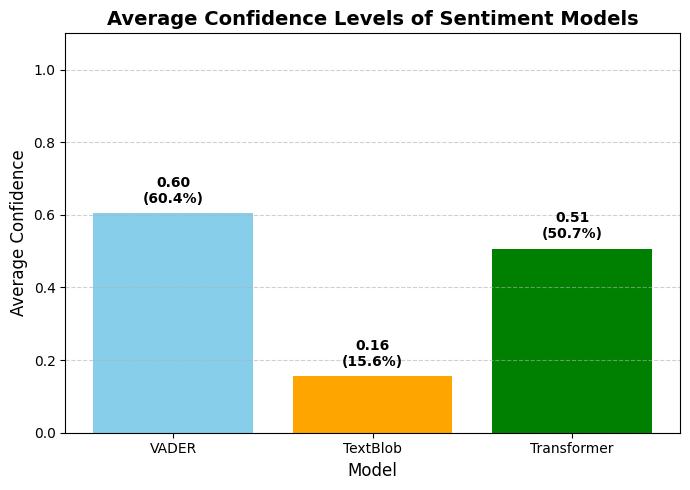

In [ ]:
avg_confidences = {
    'VADER': Dataset['vader_strength'].mean(),
    'TextBlob': Dataset['textblob_strength'].mean(),
    'Transformer': Dataset['transformer_strength'].mean()
}

plt.figure(figsize=(7, 5))
ax = plt.bar(avg_confidences.keys(), avg_confidences.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(avg_confidences.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Average Confidence Levels of Sentiment Models", fontsize=14, fontweight='bold')
plt.xlabel("Model", fontsize=12)
plt.ylabel("Average Confidence", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###### The comparison of average confidence levels reveals that the Transformer model produces the strongest and most confident sentiment predictions, followed by VADER, while TextBlob shows the weakest overall confidence on the Reddit dataset.

#### **Saving the Sentiment Labelling Dataset**

In [ ]:
Dataset.to_csv('2021_JOB_Dissatisfaction_Sentiment.csv', index=False)

In [ ]:
Dataset = pd.read_csv('2021_JOB_Dissatisfaction_Sentiment.csv')

#### **Traditional Model**

###### We will start by training with traditional model. We are using **Naive Bayes & SVM**

###### Let make a copy of our Dataset

In [ ]:
Dataframe = Dataset.copy()

#### **Naive Bayes**

#### **Naive Bayes Function**

###### So here, we’re building a balanced sentiment model. Basically, we convert our text into **TF-IDF features**, change the sentiment labels into numbers, handle **class imbalance with class weight**, train a **Naive Bayes model**, and then test how accurate it is.

In [ ]:
general_results = []

In [ ]:
Result_global = []

In [ ]:
def train_sentiment_model(dataframe, sentiment_col, use_class_weight=True):
    """
    Train a TF-IDF + MultinomialNB sentiment classifier.
    If use_class_weight=True, compute balanced class weights and pass them
    as per-sample weights to MultinomialNB.fit().
    """

    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)
    df = df[df['text_lemma'].str.strip() != '']

    # TF-IDF
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X = tfidf.fit_transform(df['text_lemma'])
    y = df['label_mapped']

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Compute class weights
    sample_weight_train = None
    if use_class_weight:
        classes = np.unique(y_train)
        weights = compute_class_weight(
            class_weight='balanced',
            classes=classes,
            y=y_train
        )
        class_weight_dict = {c: w for c, w in zip(classes, weights)}

        y_train_series = pd.Series(y_train).reset_index(drop=True)
        sample_weight_train = y_train_series.map(class_weight_dict).to_numpy()

        inv_label_map = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
        pretty_weights = {
            inv_label_map[c]: round(float(w), 4)
            for c, w in class_weight_dict.items()
        }
        print("Class weights (balanced):", pretty_weights)

    # Train model
    nb = MultinomialNB()
    nb.fit(X_train, y_train, sample_weight=sample_weight_train)

    # Predict
    y_pred = nb.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("F1 Score:", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=['Negative', 'Positive', 'Neutral']
    ))

    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_test, y_pred))

    model_result = {
        "accuracy": round(float(accuracy), 4),
        "precision": round(float(precision), 4),
        "f1_score": round(float(f1), 4),
        "use_class_weight": use_class_weight,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return nb, tfidf, accuracy, model_result

###### We’re going to train our sentiment models using the **Naive Bayes** algorithm to compare their performance. The idea is to feed in the sentiment outputs from **VADER**, **TextBlob**, and the **Transformer model** separately, and then check which one gives us the best accuracy and overall results. By doing this, we’ll be able to see which sentiment detection method works best with our dataset and produces the most reliable predictions.


#### **Vader with Naive Bayes**

In [ ]:
Vader_Naive_Bayes = train_sentiment_model(Dataframe, 'vader_sentiment')

Class weights (balanced): {'Negative': 0.718, 'Positive': 0.6772, 'Neutral': 7.6592}
Accuracy: 0.6937
Precision: 0.7388
F1 Score: 0.7123

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.72      0.73      2035
    Positive       0.78      0.69      0.74      2158
     Neutral       0.15      0.40      0.22       191

    accuracy                           0.69      4384
   macro avg       0.56      0.61      0.56      4384
weighted avg       0.74      0.69      0.71      4384


Confusion Matrix (rows=true, cols=pred):
[[1465  358  212]
 [ 439 1499  220]
 [  55   59   77]]


#### **Transformer with Naive Bayes**

In [ ]:
Transformer_Naive_Bayes = train_sentiment_model(Dataframe, 'sentiment')

Class weights (balanced): {'Negative': 0.9279, 'Positive': 1.5514, 'Neutral': 0.7826}
Accuracy: 0.622
Precision: 0.6382
F1 Score: 0.6243

Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.55      0.59      1575
    Positive       0.49      0.70      0.58       942
     Neutral       0.71      0.64      0.68      1867

    accuracy                           0.62      4384
   macro avg       0.61      0.63      0.62      4384
weighted avg       0.64      0.62      0.62      4384


Confusion Matrix (rows=true, cols=pred):
[[ 865  361  349]
 [ 140  661  141]
 [ 347  319 1201]]


#### **Text Blob with Naive Bayes**

In [ ]:
TextBlob_Naive_Bayes = train_sentiment_model(Dataframe, 'Blob_Sentiment')

Class weights (balanced): {'Negative': 0.8534, 'Positive': 0.6121, 'Neutral': 5.1398}
Accuracy: 0.7126
Precision: 0.7287
F1 Score: 0.718

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.70      0.70      1713
    Positive       0.79      0.73      0.76      2387
     Neutral       0.40      0.66      0.50       284

    accuracy                           0.71      4384
   macro avg       0.63      0.70      0.65      4384
weighted avg       0.73      0.71      0.72      4384


Confusion Matrix (rows=true, cols=pred):
[[1196  397  120]
 [ 491 1741  155]
 [  41   56  187]]


##### **Comparing the naive bayes result for the 4 labelling**

###### Let’s visualize how well each sentiment model performed after training with **Naive Bayes** This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling to see which one delivers the best overall results.

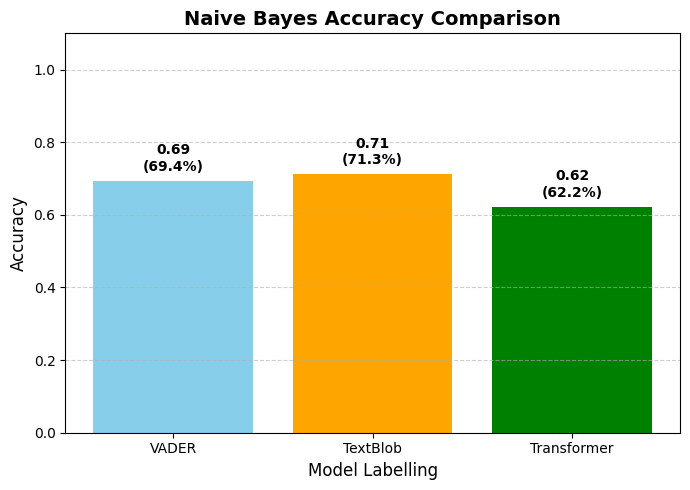

In [ ]:
Naive_Result = {
    'VADER': Vader_Naive_Bayes[2],
    'TextBlob': TextBlob_Naive_Bayes[2],
    'Transformer': Transformer_Naive_Bayes[2]
}

plt.figure(figsize=(7, 5))
ax = plt.bar(Naive_Result.keys(), Naive_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(Naive_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Naive Bayes Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model Labelling", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

###### Let’s neatly display our Naive Bayes accuracy results in a table using a DataFrame, so we can easily compare **VADER**, **TextBlob**, and **Transformer** model performances side by side.

In [ ]:
result_naive = pd.DataFrame(Naive_Result, index=[0])
display(result_naive)

,VADER,TextBlob,Transformer
0,0.693659,0.712591,0.622035


In [ ]:
print(general_results)

[{'accuracy': 0.6937, 'precision': 0.7388, 'f1_score': 0.7123, 'use_class_weight': True, 'labels': 'vader_sentiment'}, {'accuracy': 0.622, 'precision': 0.6382, 'f1_score': 0.6243, 'use_class_weight': True, 'labels': 'sentiment'}, {'accuracy': 0.7126, 'precision': 0.7287, 'f1_score': 0.718, 'use_class_weight': True, 'labels': 'Blob_Sentiment'}]


In [ ]:
data = {
    "Naive Bayes": general_results
}

Result_global.append(data)

##### **SVM (Support Vector Machine)**

###### We’re now training a sentiment model using **Support Vector Machine (LinearSVC)** instead of Naive Bayes. We map the labels, turn the cleaned text into TF-IDF features, split the data, train the SVM with class balancing, and then check accuracy, report, and confusion matrix.

In [ ]:
general_results = []

In [ ]:
def train_svm_sentiment_model(dataframe, sentiment_col):
    """
    Train a TF-IDF + LinearSVC sentiment classifier
    for labels: Negative, Positive, Neutral.

    Also computes accuracy, precision, and F1-score (weighted),
    stores them in a result object, and appends it to the global
    general_results list.
    """

    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma: replace NaN/None with "", ensure string
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)

    # Drop completely empty texts
    df = df[df['text_lemma'].str.strip() != '']

    # Text → TF-IDF features
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X = tfidf.fit_transform(df['text_lemma'])
    y = df['label_mapped'].astype(int)

    # Train/test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Train Linear SVM with balanced class weights
    svm = LinearSVC(class_weight='balanced', random_state=42)
    svm.fit(X_train, y_train)

    # Predict & evaluate
    y_pred = svm.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ['Negative', 'Positive', 'Neutral']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_test, y_pred))

    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    model_result = {
        "model_name": "LinearSVC",
        "use_class_weight": True,
        "scores": scores_array,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return svm, tfidf, accuracy, model_result

#### **Vader with SVM**

In [ ]:
Vader_SVM = train_svm_sentiment_model(Dataframe, 'vader_sentiment')

Accuracy: 0.8344
Precision (weighted): 0.8388
F1 Score (weighted): 0.8365

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86      2035
    Positive       0.86      0.86      0.86      2158
     Neutral       0.28      0.32      0.30       191

    accuracy                           0.83      4384
   macro avg       0.67      0.68      0.67      4384
weighted avg       0.84      0.83      0.84      4384


Confusion Matrix (rows=true, cols=pred):
[[1736  229   70]
 [ 206 1860   92]
 [  60   69   62]]


#### **Transformer with SVM**

In [ ]:
Transformer_SVM = train_svm_sentiment_model(Dataframe, 'sentiment')

Accuracy: 0.7288
Precision (weighted): 0.7285
F1 Score (weighted): 0.7284

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.68      0.69      1575
    Positive       0.75      0.73      0.74       942
     Neutral       0.74      0.77      0.76      1867

    accuracy                           0.73      4384
   macro avg       0.73      0.73      0.73      4384
weighted avg       0.73      0.73      0.73      4384


Confusion Matrix (rows=true, cols=pred):
[[1070  135  370]
 [ 132  683  127]
 [ 338   87 1442]]


#### **Text Blob with SVM**

In [ ]:
TextBlob_SVM = train_svm_sentiment_model(Dataframe, 'Blob_Sentiment')

Accuracy: 0.8613
Precision (weighted): 0.8623
F1 Score (weighted): 0.8617

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.84      0.85      1713
    Positive       0.89      0.89      0.89      2387
     Neutral       0.67      0.73      0.70       284

    accuracy                           0.86      4384
   macro avg       0.81      0.82      0.81      4384
weighted avg       0.86      0.86      0.86      4384


Confusion Matrix (rows=true, cols=pred):
[[1447  223   43]
 [ 207 2123   57]
 [  41   37  206]]


#### **Comparing the 4 result for SVM**

###### Let’s visualize how each sentiment model performed when trained with **SVM**! This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling, helping us see which one delivers the highest performance with the SVM classifier.


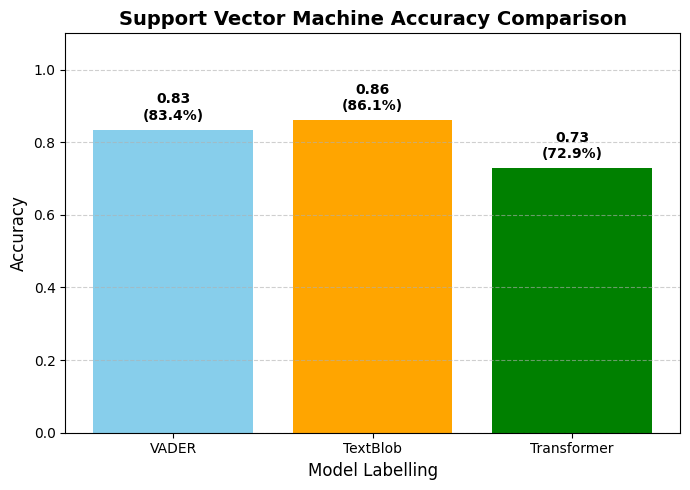

In [ ]:
SVM_Result = {
    'VADER': Vader_SVM[2],
    'TextBlob': TextBlob_SVM[2],
    'Transformer': Transformer_SVM[2]
}

plt.figure(figsize=(7, 5))
ax = plt.bar(SVM_Result.keys(), SVM_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(SVM_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

plt.title("Support Vector Machine Accuracy Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Model Labelling", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
result_svm = pd.DataFrame(SVM_Result, index=[0])
display(result_svm)

,VADER,TextBlob,Transformer
0,0.834398,0.861314,0.728786


In [ ]:
data = {
    "SVM": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.6937,
    'precision': 0.7388,
    'f1_score': 0.7123,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.622,
    'precision': 0.6382,
    'f1_score': 0.6243,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.7126,
    'precision': 0.7287,
    'f1_score': 0.718,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8388, 0.8344, 0.8365],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.7285, 0.7288, 0.7284],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8623, 0.8613, 0.8617],
    'labels': 'Blob_Sentiment'}]}]

### **Deep Learning Model**

###### We’re going to build two deep learning models **BERT** and a **CNN for text** to train and compare performance across the **VADER**, **TextBlob**, and **Transformer** sentiment datasets.

###### Let make the copy of the dataset

In [ ]:
df = Dataset.copy()

#### **CNN for Text**

###### We’re training a **CNN-based deep learning model** for sentiment analysis. The text is tokenized, padded, and converted into embeddings so the model can learn meaningful word patterns. Using convolutional and dense layers, it classifies posts as **Positive**, **Negative**, or **Neutral**, while class weights ensure balanced learning and accurate evaluation results.

In [ ]:
general_results = []

In [ ]:
def train_cnn_sentiment_model(
    dataframe, sentiment_col, max_words=10000, max_len=200,
    embedding_dim=100, epochs=5, batch_size=64
):
    df = dataframe.copy()

    # Map sentiment labels to numeric values
    label_map = {'Negative': 0, 'Positive': 1, 'Neutral': 2}
    df['label_mapped'] = df[sentiment_col].map(label_map)

    # Drop rows where sentiment is missing or unmapped
    df = df.dropna(subset=['label_mapped'])

    # Clean text_lemma
    df['text_lemma'] = df['text_lemma'].fillna('').astype(str)
    df = df[df['text_lemma'].str.strip() != '']

    y = df['label_mapped'].values

    # Tokenize text data
    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(df['text_lemma'])
    sequences = tokenizer.texts_to_sequences(df['text_lemma'])
    X = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # Compute class weights
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )
    class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}
    print("\nClass Weights:", class_weight_dict)

    # Build CNN model
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')  # 3 classes: Negative, Positive, Neutral
    ])

    # Compile model
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    # Train model with class weights
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        verbose=1
    )

    # Evaluate model
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ['Negative', 'Positive', 'Neutral']
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Build scores array [precision, accuracy, f1]
    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    # Build result object
    model_result = {
        "model_name": "CNN",
        "use_class_weight": True,
        "scores": scores_array,
        "labels": sentiment_col
    }

    general_results.append(model_result)

    return model, tokenizer, accuracy, model_result

In [ ]:
print("NaNs in text_lemma:", df['text_lemma'].isna().sum())
print("Types in text_lemma:", df['text_lemma'].apply(type).value_counts())

NaNs in text_lemma: 9
Types in text_lemma: text_lemma
<class 'str'>      21916
<class 'float'>        9
Name: count, dtype: int64


In [ ]:
df['text_lemma'] = df['text_lemma'].fillna('')

df = df[~df['text_lemma'].apply(lambda x: isinstance(x, float))]

df['text_lemma'] = df['text_lemma'].astype(str)

print("NaNs in text_lemma:", df['text_lemma'].isna().sum())
print("Types in text_lemma:", df['text_lemma'].apply(type).value_counts())

NaNs in text_lemma: 0
Types in text_lemma: text_lemma
<class 'str'>    21925
Name: count, dtype: int64


#### **CNN with Vader Sentiment**

In [ ]:
Vader_CNN = train_cnn_sentiment_model(df, 'vader_sentiment')


Class Weights: {0: np.float64(0.7180243273129377), 1: np.float64(0.6771726535341831), 2: np.float64(7.659239842726081)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.4338 - loss: 1.0594 - val_accuracy: 0.6397 - val_loss: 0.8360
Epoch 2/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7060 - loss: 0.7566 - val_accuracy: 0.7719 - val_loss: 0.6262
Epoch 3/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8113 - loss: 0.5441 - val_accuracy: 0.7999 - val_loss: 0.5654
Epoch 4/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8756 - loss: 0.3470 - val_accuracy: 0.7965 - val_loss: 0.5342
Epoch 5/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9199 - loss: 0.2176 - val_accuracy: 0.8010 - val_loss: 0.5535
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Accuracy: 0.7883
Precision (weighted): 0.7941
F1 Score (weighted): 0.7909

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.79      0.80      2035
    Positive       0.82      0.83      0.82      2158
     Neutral       0.28      0.35      0.31       191

    a

#### **CNN with Transformer**

In [ ]:
Transformer_CNN = train_cnn_sentiment_model(df, 'sentiment')


Class Weights: {0: np.float64(0.9279136233724992), 1: np.float64(1.5513671356517122), 2: np.float64(0.7826436319807152)}
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4228 - loss: 1.0118 - val_accuracy: 0.7252 - val_loss: 0.6694
Epoch 2/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7630 - loss: 0.5742 - val_accuracy: 0.7685 - val_loss: 0.5645
Epoch 3/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8481 - loss: 0.3940 - val_accuracy: 0.7634 - val_loss: 0.5579
Epoch 4/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9095 - loss: 0.2458 - val_accuracy: 0.7662 - val_loss: 0.6525
Epoch 5/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9420 - loss: 0.1654 - val_accuracy: 0.7554 - val_loss: 0.7661
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Accuracy: 0.7568
Precision (weighted): 0.7564
F1 Score (weighted): 0.7552

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.66      0.70      1575
    Positive       0.74      0.85      0.80       942
     Neutral       0.78      0.79      0.78      1867

    accuracy    

#### **CNN with Text Blob**

In [ ]:
TextBlob_CNN = train_cnn_sentiment_model(df, 'Blob_Sentiment')


Class Weights: {0: np.float64(0.8533878504672897), 1: np.float64(0.6121294647533256), 2: np.float64(5.139841688654354)}
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


247/247 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5579 - loss: 0.8762 - val_accuracy: 0.7531 - val_loss: 0.5732
Epoch 2/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7773 - loss: 0.4184 - val_accuracy: 0.8039 - val_loss: 0.4611
Epoch 3/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8564 - loss: 0.2857 - val_accuracy: 0.8318 - val_loss: 0.4157
Epoch 4/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9071 - loss: 0.1887 - val_accuracy: 0.8449 - val_loss: 0.3949
Epoch 5/5
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9489 - loss: 0.1055 - val_accuracy: 0.8364 - val_loss: 0.4458
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Accuracy: 0.8273
Precision (weighted): 0.8277
F1 Score (weighted): 0.8264

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.76      0.79      1713
    Positive       0.84      0.88      0.86      2387
     Neutral       0.73      0.79      0.76       284

    accuracy    

#### **Comparison of the 4 for CNN**

###### Let’s visualize how well our **CNN models** performed! This bar chart compares the accuracy of **VADER**, **TextBlob**, and **Transformer** sentiment labelling, with percentage values displayed on each bar to clearly show which model achieved the best performance.

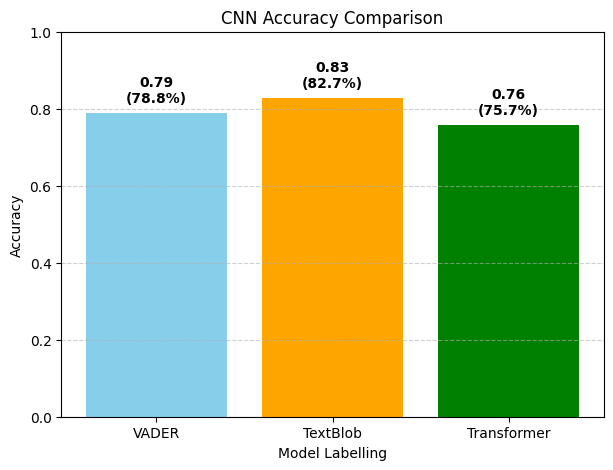

In [ ]:
CNN_Result = {
    'VADER': Vader_CNN[2],
    'TextBlob': TextBlob_CNN[2],
    'Transformer': Transformer_CNN[2],
}

plt.figure(figsize=(7,5))
ax = plt.bar(CNN_Result.keys(), CNN_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(CNN_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')


plt.bar(CNN_Result.keys(), CNN_Result.values(), color=['skyblue','orange','green'])
plt.title("CNN Accuracy Comparison")
plt.xlabel("Model Labelling")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###### Let’s display the **CNN model results** in a clean table using a DataFrame. This makes it easy to compare the accuracies of **VADER**, **TextBlob**, and **Transformer** sentiment models side by side and identify which one performed best.

In [ ]:
result_CNN = pd.DataFrame(CNN_Result, index=[0])
display(result_CNN)

,VADER,TextBlob,Transformer
0,0.788321,0.827327,0.756843


In [ ]:
data = {
    "CNN": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.6937,
    'precision': 0.7388,
    'f1_score': 0.7123,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.622,
    'precision': 0.6382,
    'f1_score': 0.6243,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.7126,
    'precision': 0.7287,
    'f1_score': 0.718,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8388, 0.8344, 0.8365],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.7285, 0.7288, 0.7284],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8623, 0.8613, 0.8617],
    'labels': 'Blob_Sentiment'}]},
 {'CNN': [{'model_name': 'CNN',
    'use_class_weight': True,
    'scores': [0.7941, 0.7883, 0.7909],
    'labels': 'vader_sentiment'},
   {'model_name': 'CNN',
    'use_clas

#### **Using Transformer BERT**

###### We’re fine-tuning a BERT model for sentiment analysis. We take the cleaned text, map each sentiment (Negative, Positive, Neutral) to numbers, split into train/test, tokenize with a pretrained BERT tokenizer, and train a sequence classification model. After training, we measure performance using accuracy, a classification report, and a confusion matrix.

In [ ]:
general_results = []

In [ ]:
class _SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item


def train_bert_sentiment_model(
    dataframe,
    sentiment_col,
    text_col="text_lemma",
    model_name="bert-base-uncased",
    max_len=128,
    epochs=2,
    batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    random_state=42
):
    # Map labels
    label_map = {"Negative": 0, "Positive": 1, "Neutral": 2}
    df = dataframe[[text_col, sentiment_col]].dropna().copy()
    df["label_mapped"] = df[sentiment_col].map(label_map)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_col].tolist(),
        df["label_mapped"].tolist(),
        test_size=0.2,
        stratify=df["label_mapped"],
        random_state=random_state
    )

    # Tokenizer & encodings
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    train_enc = tokenizer(
        X_train, truncation=True, padding=False, max_length=max_len
    )
    test_enc = tokenizer(
        X_test, truncation=True, padding=False, max_length=max_len
    )

    train_ds = _SimpleDataset(train_enc, y_train)
    test_ds = _SimpleDataset(test_enc, y_test)

    # Model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=3
    )

    collator = DataCollatorWithPadding(tokenizer=tokenizer)
    args = TrainingArguments(
        output_dir="bert_sentiment_outputs",
        eval_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        report_to=[]
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        tokenizer=tokenizer,
        data_collator=collator,
    )

    # Train
    trainer.train()

    # Predict
    preds = trainer.predict(test_ds)
    y_pred = np.argmax(preds.predictions, axis=1)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("\nAccuracy:", round(accuracy, 4))
    print("Precision (weighted):", round(precision, 4))
    print("F1 Score (weighted):", round(f1, 4))

    print("\nClassification Report:")
    target_names = ["Negative", "Positive", "Neutral"]
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    scores_array = [
        round(float(precision), 4),
        round(float(accuracy), 4),
        round(float(f1), 4)
    ]

    model_result = {
        "model_name": f"BERT ({model_name})",
        "use_class_weight": False,
        "scores": scores_array,
        "labels": sentiment_col
    }

    # Push into global results
    general_results.append(model_result)

    return model, tokenizer, trainer, accuracy, model_result

#### **Transformer with Vader**

In [ ]:
Vader_BERT = train_bert_sentiment_model(df, 'vader_sentiment', model_name="distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.512700,0.380540
2,0.304600,0.359126



Accuracy: 0.867
Precision (weighted): 0.8635
F1 Score (weighted): 0.8623

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.88      0.88      2035
    Positive       0.87      0.90      0.88      2158
     Neutral       0.71      0.34      0.46       192

    accuracy                           0.87      4385
   macro avg       0.82      0.71      0.74      4385
weighted avg       0.86      0.87      0.86      4385


Confusion Matrix:
[[1794  227   14]
 [ 203 1942   13]
 [  54   72   66]]


#### **Transformer with Transformer**

In [ ]:
Transformer_BERT = train_bert_sentiment_model(df, 'sentiment')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.567200,0.399540
2,0.298700,0.433387



Accuracy: 0.8456
Precision (weighted): 0.8496
F1 Score (weighted): 0.8462

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.85      0.82      1574
    Positive       0.84      0.89      0.86       942
     Neutral       0.90      0.82      0.86      1869

    accuracy                           0.85      4385
   macro avg       0.84      0.85      0.85      4385
weighted avg       0.85      0.85      0.85      4385


Confusion Matrix:
[[1340  115  119]
 [  64  836   42]
 [ 292   45 1532]]


#### **Transformer with Transformer**

In [ ]:
TextBlob_BERT = train_bert_sentiment_model(df, 'Blob_Sentiment')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1217991567.py:70: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,0.471100,0.324330
2,0.271900,0.322602



Accuracy: 0.8848
Precision (weighted): 0.8846
F1 Score (weighted): 0.8844

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.85      0.86      1712
    Positive       0.89      0.92      0.91      2387
     Neutral       0.87      0.81      0.84       286

    accuracy                           0.88      4385
   macro avg       0.88      0.86      0.87      4385
weighted avg       0.88      0.88      0.88      4385


Confusion Matrix:
[[1451  240   21]
 [ 176 2197   14]
 [  23   31  232]]


#### **Comparison of the 3 for BERT**

###### Let’s visualize how well our **BERT models** performed across different sentiment labelling methods **VADER**, **TextBlob**, and **Transformer**. This bar chart compares their accuracy to reveal which dataset helped BERT achieve the best performance and most reliable predictions.


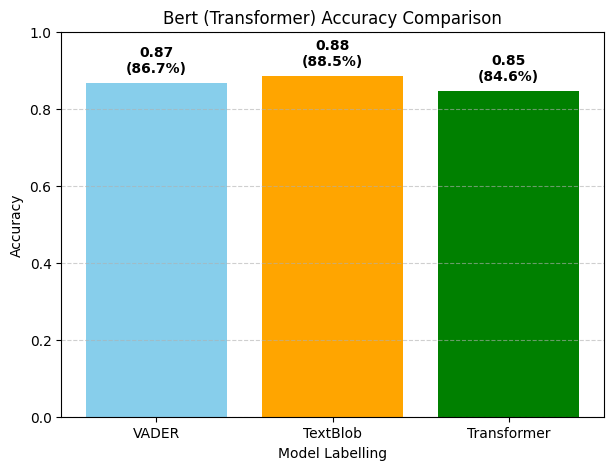

In [ ]:
BERT_Result = {
    'VADER': Vader_BERT[3],
    'TextBlob': TextBlob_BERT[3],
    'Transformer': Transformer_BERT[3]
}
plt.figure(figsize=(7,5))
ax = plt.bar(BERT_Result.keys(), BERT_Result.values(),
             color=['skyblue', 'orange', 'green'])

for i, (model, value) in enumerate(BERT_Result.items()):
    percent = value * 100
    plt.text(i, value + 0.02,
             f"{value:.2f}\n({percent:.1f}%)",  # shows both
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')


plt.bar(BERT_Result.keys(), BERT_Result.values(), color=['skyblue','orange','green'])
plt.title("Bert (Transformer) Accuracy Comparison")
plt.xlabel("Model Labelling")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

###### Let’s neatly display our **BERT model results** in a table using a DataFrame. This makes it easy to compare the accuracy of **VADER**, **TextBlob**, and **Transformer** labelling side by side and identify which one produced the best overall performance.

In [ ]:
result_bert = pd.DataFrame(BERT_Result, index=[0])
display(result_bert)

,VADER,TextBlob,Transformer
0,0.867047,0.884835,0.84561


In [ ]:
data = {
    "Transformer": general_results
}

Result_global.append(data)

In [ ]:
display(Result_global)

[{'Naive Bayes': [{'accuracy': 0.6937,
    'precision': 0.7388,
    'f1_score': 0.7123,
    'use_class_weight': True,
    'labels': 'vader_sentiment'},
   {'accuracy': 0.622,
    'precision': 0.6382,
    'f1_score': 0.6243,
    'use_class_weight': True,
    'labels': 'sentiment'},
   {'accuracy': 0.7126,
    'precision': 0.7287,
    'f1_score': 0.718,
    'use_class_weight': True,
    'labels': 'Blob_Sentiment'}]},
 {'SVM': [{'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8388, 0.8344, 0.8365],
    'labels': 'vader_sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.7285, 0.7288, 0.7284],
    'labels': 'sentiment'},
   {'model_name': 'LinearSVC',
    'use_class_weight': True,
    'scores': [0.8623, 0.8613, 0.8617],
    'labels': 'Blob_Sentiment'}]},
 {'CNN': [{'model_name': 'CNN',
    'use_class_weight': True,
    'scores': [0.7941, 0.7883, 0.7909],
    'labels': 'vader_sentiment'},
   {'model_name': 'CNN',
    'use_clas

#### **Overall comparison for the 4 Model to know the best model**

###### Here we’re bringing everything together! This dictionary stores the **accuracy results** of all four models — **Naive Bayes**, **SVM**, **CNN**, and **BERT**. for each sentiment labelling method (**VADER**, **TextBlob**, and **Transformer**) so we can easily compare their performances later.

In [ ]:
results = {
    "CNN": {"VADER": Vader_CNN[2], "TextBlob": TextBlob_CNN[2], "Transformer": Transformer_CNN[2]},
    "SVM": {"VADER": Vader_SVM[2], "TextBlob": TextBlob_SVM[2], "Transformer": Transformer_SVM[2]},
    "Naive Bayes": {"VADER": Vader_Naive_Bayes[2], "TextBlob": TextBlob_Naive_Bayes[2], "Transformer": Transformer_Naive_Bayes[2]},
    "BERT": {"VADER": Vader_BERT[3], "TextBlob": TextBlob_BERT[3], "Transformer": Transformer_BERT[3]},
}

###### Let’s organize all our model performances into a clean table! By converting the results dictionary into a DataFrame, we can easily compare how **Naive Bayes**, **SVM**, **CNN**, and **BERT** performed across **VADER**, **TextBlob**, and **Transformer** labels all neatly rounded for clarity.

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

display(results_df)

,VADER,TextBlob,Transformer
CNN,0.7883,0.8273,0.7568
SVM,0.8344,0.8613,0.7288
Naive Bayes,0.6937,0.7126,0.6220
BERT,0.8670,0.8848,0.8456


###### Let’s visualize the overall performance of all our models! This bar chart compares the accuracies of **Naive Bayes**, **SVM**, **CNN**, and **BERT** across the three sentiment sources **VADER**, **TextBlob**, and **Transformer** to clearly see which combination performed best.

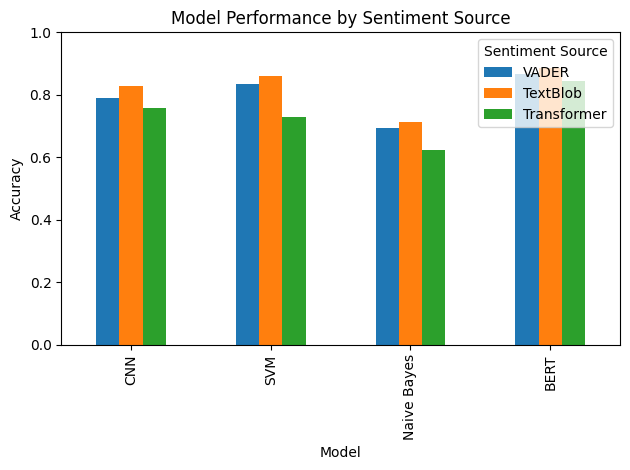

In [ ]:
ax = results_df.plot(kind='bar')
ax.set_title("Model Performance by Sentiment Source")
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.legend(title="Sentiment Source", loc="best")
plt.tight_layout()
plt.show()

###### Let’s find out which model performed best for each sentiment source! This code checks the **highest accuracy** in each column and prints the **top-performing model** for **VADER**, **TextBlob**, and **Transformer** sentiment labelling.

In [ ]:
best_scores = results_df.idxmax()
print("Best models per sentiment source:")
print(best_scores)

Best models per sentiment source:
VADER          BERT
TextBlob       BERT
Transformer    BERT
dtype: object


###### Let’s create a **heatmap** to visualize model performance more clearly! Each cell shows the accuracy of **Naive Bayes**, **SVM**, **CNN**, and **BERT** across **VADER**, **TextBlob**, and **Transformer** labels, making it easy to spot the strongest results at a glance.

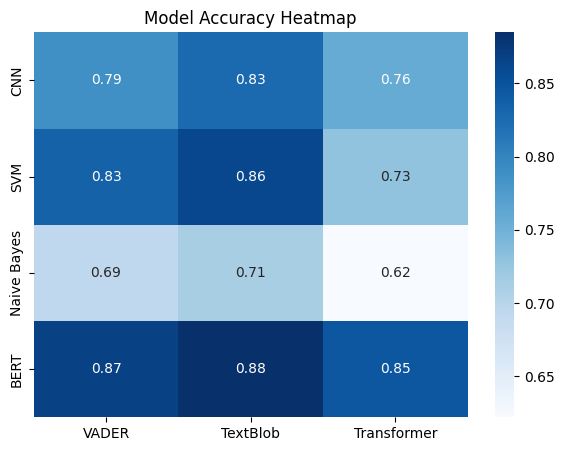

In [ ]:
plt.figure(figsize=(7,5))
sns.heatmap(results_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Model Accuracy Heatmap")
plt.show()

##### **Overall Labelling**

###### Let’s calculate the **average accuracy** for each sentiment source across all models. This helps us see whether **VADER**, **TextBlob**, or **Transformer** generally provided better training data for sentiment prediction overall.

In [ ]:
avg_scores = results_df.mean().sort_values(ascending=False)
print(avg_scores)

TextBlob       0.82150
VADER          0.79585
Transformer    0.73830
dtype: float64


###### Let’s visualize the **average accuracy** of each sentiment source across all models! This bar chart clearly shows whether **VADER**, **TextBlob**, or **Transformer** produced better overall results when used to train different sentiment classifiers.

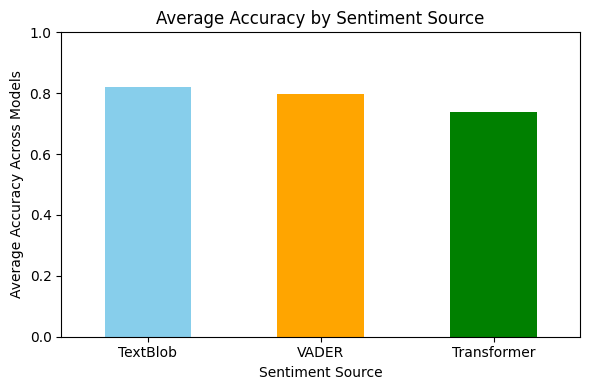

In [ ]:
plt.figure(figsize=(6,4))
avg_scores.plot(kind='bar', color=['skyblue', 'orange', 'green', 'red'])

plt.title('Average Accuracy by Sentiment Source')
plt.xlabel('Sentiment Source')
plt.ylabel('Average Accuracy Across Models')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###### Let’s identify the **best overall sentiment source** This code finds which dataset **VADER**, **TextBlob**, or **Transformer** achieved the **highest average accuracy** across all models, then prints the top performer along with its exact score.

In [ ]:
best_source = avg_scores.idxmax()
best_score = avg_scores.max()
print(f"Best performing sentiment source: {best_source} ({best_score:.3f})")

Best performing sentiment source: TextBlob (0.822)


#### **For Model**

###### Let’s now check which **model** performed best on average across all sentiment sources. This code calculates the mean accuracy for each model  **Naive Bayes**, **SVM**, **CNN**, and **BERT** helping us see which one delivered the most consistent overall performance.

In [ ]:
avg_model_scores = results_df.mean(axis=1).sort_values(ascending=False)
print(avg_model_scores)

BERT           0.865800
SVM            0.808167
CNN            0.790800
Naive Bayes    0.676100
dtype: float64


###### Let’s visualize how each **model** performed on average across all sentiment sources! This bar chart compares the overall accuracy of **Naive Bayes**, **SVM**, **CNN**, and **BERT**, helping us easily see which model achieved the strongest and most reliable performance.

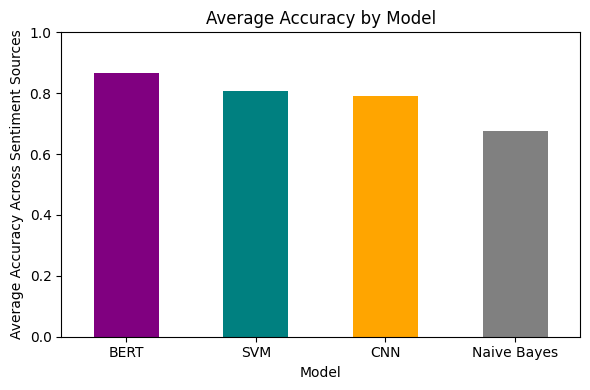

In [ ]:
plt.figure(figsize=(6,4))
avg_model_scores.plot(kind='bar', color=['purple', 'teal', 'orange', 'gray'])

plt.title('Average Accuracy by Model')
plt.xlabel('Model')
plt.ylabel('Average Accuracy Across Sentiment Sources')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

###### Let’s find out which **model** performed the best overall! This code identifies the model whether **Naive Bayes**, **SVM**, **CNN**, or **BERT** with the **highest average accuracy** across all sentiment sources and prints it along with its exact score.

In [ ]:
best_model = avg_model_scores.idxmax()
best_score = avg_model_scores.max()
print(f"Best performing model overall: {best_model} ({best_score:.3f})")

Best performing model overall: BERT (0.866)


###### Let’s save our cleaned and processed dataset! This line exports the entire **DataFrame** to a CSV file named **“Updated_Data.csv”**, excluding the index column, so we can easily reuse it for future analysis or modeling.

In [ ]:
Dataframe.to_csv('Updated_Data.csv', index=False)

#### Let save the result into JSOn file so we can use it later

In [ ]:
with open("model_results.json", "r") as f:
    data = json.load(f)

print(data)

{'2020': [{'Naive Bayes': [{'accuracy': 0.6849, 'precision': 0.7254, 'f1_score': 0.7022, 'use_class_weight': True, 'labels': 'vader_sentiment'}, {'accuracy': 0.609, 'precision': 0.6354, 'f1_score': 0.6131, 'use_class_weight': True, 'labels': 'sentiment'}, {'accuracy': 0.7092, 'precision': 0.7184, 'f1_score': 0.7123, 'use_class_weight': True, 'labels': 'Blob_Sentiment'}]}, {'SVM': [{'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.8061, 0.8094, 0.8077], 'labels': 'vader_sentiment'}, {'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.712, 0.7134, 0.7124], 'labels': 'sentiment'}, {'model_name': 'LinearSVC', 'use_class_weight': True, 'scores': [0.8294, 0.8303, 0.8297], 'labels': 'Blob_Sentiment'}, {'model_name': 'CNN', 'use_class_weight': True, 'scores': [0.7618, 0.7578, 0.7597], 'labels': 'vader_sentiment'}, {'model_name': 'CNN', 'use_class_weight': True, 'scores': [0.7418, 0.7339, 0.7361], 'labels': 'sentiment'}, {'model_name': 'CNN', 'use_class_weight': 

In [ ]:
data['2021'] = Result_global

with open("model_results.json", "w") as file:
    json.dump(data, file, indent=4)

print("Result Saved Successfully")

Result Saved Successfully


### **Topic Modelling**

###### Topic modelling helps uncover hidden themes in text data, like identifying key reasons behind employee concerns in a **job dissatisfaction** dataset.

#### **LDA - Latent Dirichlet Allocation**

In [7]:
data = pd.read_csv('2021_JOB_Dissatisfaction_Sentiment.csv')

In [8]:
display(data)

,id,created_utc,year,subreddit,label,text_raw,text_clean,text_lemma,compound,vader_sentiment,...,Blob_Sentiment,neg,neu,pos,sentiment,all_agree,two_or_more_agree,vader_strength,textblob_strength,transformer_strength
0,kx4b32,1610625565,2021,antiwork,Negative,I want to preface this by saying I have been a...,i want to preface this by saying i have been a...,I want preface say I anti work long time know ...,0.9778,Positive,...,Positive,0.092485,0.357545,0.257851,Neutral,False,True,0.9778,0.159743,0.357545
1,lwp19v,1614760350,2021,antiwork,Negative,I hate being a manager. I feel like I've reall...,i hate being a manager i feel like i've really...,I hate manager I feel like I really pull back ...,-0.8852,Negative,...,Negative,0.047666,0.022124,0.034357,Negative,True,True,0.8852,0.052921,0.047666
2,lyf62f,1614960550,2021,antiwork,Negative,I work in a company that I can't really name h...,i work in a company that i can't really name h...,I work company I really name suffice say huge ...,0.9229,Positive,...,Positive,0.026565,0.428132,0.015284,Negative,False,True,0.9229,0.023620,0.428132
3,m32djq,1615501254,2021,antiwork,Negative,For the past 2 years I’ve been running a compa...,for the past 2 years i ve been running a compa...,past year I run company boss without acknowled...,0.8261,Positive,...,Positive,0.041195,0.568563,0.031598,Neutral,False,True,0.8261,0.152056,0.568563
4,m74e06,1615998760,2021,antiwork,Negative,I hate my job. I hate the soul-sucking work we...,i hate my job i hate the soul sucking work we ...,I hate job I hate soul suck work penny I hate ...,-0.9972,Negative,...,Negative,0.022063,0.012565,0.022001,Negative,True,True,0.9972,0.196134,0.022063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21289,hqqbx8q,1640986561,2021,unitedkingdom,Negative,"&gt; He said ""Any prime minister that lied to ...",gt he said any prime minister that lied to par...,gt say prime minister lie parliament would res...,-0.9081,Negative,...,Negative,0.366255,0.033111,0.031448,Negative,True,True,0.9081,0.133333,0.366255
21290,hqqgque,1640988694,2021,unitedkingdom,Negative,A lot of the rules about proper conduct for a ...,a lot of the rules about proper conduct for a ...,lot rule proper conduct politician technically...,0.6249,Positive,...,Positive,0.014609,0.217896,0.005739,Negative,False,True,0.6249,0.020040,0.217896
21291,hqqk1p0,1640990156,2021,unitedkingdom,Negative,His media advisor told him not to do the inter...,his media advisor told him not to do the inter...,medium advisor tell interview resign insist go...,-0.3400,Negative,...,Neutral,0.014058,0.752392,0.005369,Neutral,False,True,0.3400,0.000000,0.752392
21292,hqqm8zj,1640991162,2021,unitedkingdom,Negative,&gt;There wasn't a single pro-EU or pro-remain...,gt there wasn't a single pro eu or pro remain ...,gt single pro eu pro remain comment tweet post...,-0.7506,Negative,...,Positive,0.033317,0.426149,0.010106,Neutral,False,False,0.7506,0.009524,0.426149


#### **LDA**

##### Let's converts the lemmatized text into numerical feature vectors using the **Bag-of-Words** method, removes common **English stopwords**, and safely handles any **missing values**.

In [10]:
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['text_lemma'].fillna(''))

##### We are going to loop through different numbers of topics, train an LDA model for each one and calculate the perplexity score and plot the results to find the best number of topics.

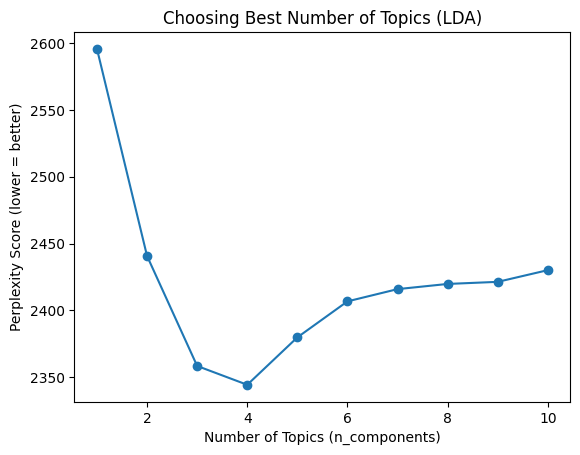

In [11]:
scores = []
topics = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for n in topics:
    lda = LatentDirichletAllocation(n_components=n, random_state=42)
    lda.fit(X)
    score = lda.perplexity(X)
    scores.append(score)

plt.plot(topics, scores, marker='o')
plt.title("Choosing Best Number of Topics (LDA)")
plt.xlabel("Number of Topics (n_components)")
plt.ylabel("Perplexity Score (lower = better)")
plt.show()

##### Train the LDA model with 4 topics, then extract and display the top 10 most important words for each topic.

In [12]:
lda = LatentDirichletAllocation(n_components=4, random_state=42)
lda.fit(X)

words = vectorizer.get_feature_names_out()
num_words = 10

for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[-num_words:]]
    print(f"Topic {i+1}: {', '.join(top_words)}")

Topic 1: want, make, company, year, time, hour, people, pay, job, work
Topic 2: thing, really, bad, make, say, like, think, unreasonable, gt, people
Topic 3: johnson, vote, minister, labour, tory, government, party, gt, say, resign
Topic 4: feel, make, think, day, work, people, time, like, bad, really


##### Get the topic probability distribution for each document in the dataset.

In [13]:
doc_topic_dist = lda.transform(X)

##### Assign each document to the topic with the highest probability.

In [17]:
data['topic_LDA'] = doc_topic_dist.argmax(axis=1)

##### Create and display a dictionary that assigns meaningful names to each LDA topic.

In [18]:
Topic_suggestion = {
    "Topic 1": "Jobs, Pay & Working Hours",
    "Topic 2": "General Frustration & Unreasonable Situations",
    "Topic 3": "UK Politics",
    "Topic 4": "Work-Related Feelings & Stress"
}

print(Topic_suggestion)

{'Topic 1': 'Jobs, Pay & Working Hours', 'Topic 2': 'General Frustration & Unreasonable Situations', 'Topic 3': 'UK Politics', 'Topic 4': 'Work-Related Feelings & Stress'}


##### Map each numeric topic to its descriptive name and add it as a new column in the dataset.

In [19]:
topic_label_map = {i: Topic_suggestion[f"Topic {i+1}"] for i in range(4)}
data['topic_label_LDA'] = data['topic_LDA'].map(topic_label_map)

##### Let's group the data by topic and sentiment, then count how many records fall into each group.

In [20]:
sentiment_summary = (
    data.groupby(['topic_label_LDA', 'sentiment'])
      .size()
      .reset_index(name='count')
)
display(sentiment_summary)

,topic_label_LDA,sentiment,count
0,General Frustration & Unreasonable Situations,Negative,1146
1,General Frustration & Unreasonable Situations,Neutral,1754
2,General Frustration & Unreasonable Situations,Positive,380
3,"Jobs, Pay & Working Hours",Negative,2512
4,"Jobs, Pay & Working Hours",Neutral,3887
5,"Jobs, Pay & Working Hours",Positive,1790
6,UK Politics,Negative,677
7,UK Politics,Neutral,1582
8,UK Politics,Positive,232
9,Work-Related Feelings & Stress,Negative,3340


##### Let draw a chat to show the relationship among the two of them

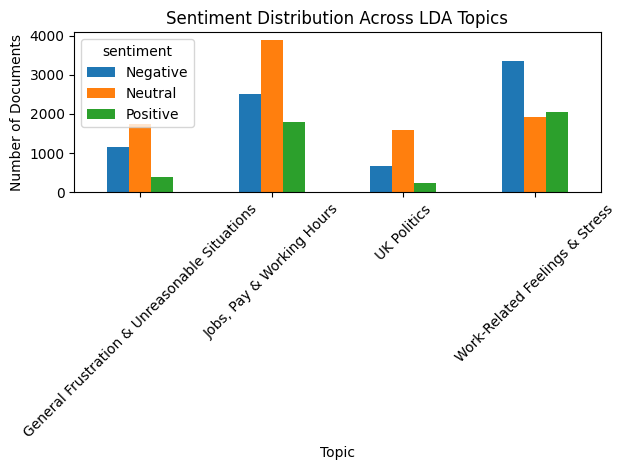

In [21]:
pivot_table = sentiment_summary.pivot(
    index='topic_label_LDA',
    columns='sentiment',
    values='count'
).fillna(0)

# Plot the bar chart
pivot_table.plot(kind='bar')

plt.title("Sentiment Distribution Across LDA Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Documents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### **Create the Table**

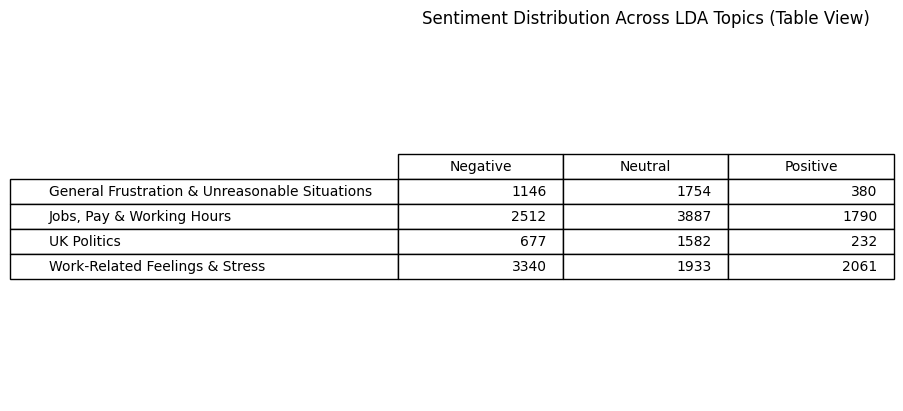

In [22]:
pivot_table = sentiment_summary.pivot(
    index='topic_label_LDA',
    columns='sentiment',
    values='count'
).fillna(0)

fig, ax = plt.subplots()
ax.axis('off')

table = ax.table(
    cellText=pivot_table.values,
    colLabels=pivot_table.columns,
    rowLabels=pivot_table.index,
    loc='center'
)

table.scale(1, 1.5)

plt.title("Sentiment Distribution Across LDA Topics (Table View)")
plt.show()

##### Let's build a Gensim LDA model and evaluate its topic quality using the coherence score.

In [23]:
corpus = [vectorizer.inverse_transform(x)[0] for x in X]
dictionary = Dictionary(corpus)

bow_corpus = [dictionary.doc2bow(doc) for doc in corpus]

lda_gensim = LdaModel(bow_corpus, num_topics=7, id2word=dictionary, passes=15, random_state=42)


coherence_model = CoherenceModel(model=lda_gensim, texts=corpus, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print("Coherence Score:", coherence_score)

Coherence Score: 0.6964993028633184


#### **Saving Results**

In [24]:
lda_json = {}

for _, row in sentiment_summary.iterrows():
    topic = row["topic_label_LDA"]
    sentiment = row["sentiment"]
    count = int(row["count"])

    if topic not in lda_json:
        lda_json[topic] = {}

    lda_json[topic][sentiment] = count


final_lda_json = {
    "LDA_Sentiment_Summary": lda_json
}
print(final_lda_json)

{'LDA_Sentiment_Summary': {'General Frustration & Unreasonable Situations': {'Negative': 1146, 'Neutral': 1754, 'Positive': 380}, 'Jobs, Pay & Working Hours': {'Negative': 2512, 'Neutral': 3887, 'Positive': 1790}, 'UK Politics': {'Negative': 677, 'Neutral': 1582, 'Positive': 232}, 'Work-Related Feelings & Stress': {'Negative': 3340, 'Neutral': 1933, 'Positive': 2061}}}


### **Bertopic**

###### BERTopic is a topic modeling technique that uses BERT embeddings to generate coherent and meaningful topics from large text datasets.

###### Download the list of common stopwords used for text preprocessing

In [ ]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

###### Let's removes automated moderator messages using predefined text patterns and keeps only genuine user-generated content for analysis.

In [26]:
patterns_to_remove = [
    "thank posting",
    "please help keep",
    "welcoming",
    "moderators",
    "megathread",
    "submissionpost",
    "automatically",
    "contact the moderators",
    "if you have a concern",
    "replying submissionpost",
    "help us make better",
]


def remove_auto_mod(text):
    for p in patterns_to_remove:
        if p in text.lower():
            return None
    return text

data["filtered_text"] = data["text_raw"].apply(remove_auto_mod)
data = data.dropna(subset=["filtered_text"])
documents = data["filtered_text"].tolist()

##### Let's converts the cleaned text column into a list of documents for further analysis.

In [27]:
documents = data["filtered_text"].tolist()

###### Let's set up and runs a customized BERTopic pipeline using Sentence-BERT embeddings, CountVectorizer, UMAP for dimensionality reduction, and HDBSCAN for clustering to generate well-separated, fine-grained topics from the text documents.

In [28]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=10
)

#UMAP – more separation, more topics
umap_model = UMAP(
    n_neighbors=5,
    n_components=15,
    min_dist=0.0,
    random_state=42
)

# HDBSCAN – allow smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=80,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

# BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    min_topic_size=10,
    nr_topics=None
)

topics, probs = topic_model.fit_transform(documents)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

##### Let retrieves a summary table of all discovered topics, including their sizes and labels.

In [29]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4635,-1_people_really_just_work,"[people, really, just, work, https, like, job,...",[Change is scary -better the devil you know th...
1,0,1203,0_nhs_doctors_gp_care,"[nhs, doctors, gp, care, nurses, pay, underpai...","[Since you ask, my uncle's one and he spends p..."
2,1,874,1_working_flexible_office_flexible working,"[working, flexible, office, flexible working, ...",[Any company that mandates office staff to be ...
3,2,854,2_resign_resigned_resigning_resignation,"[resign, resigned, resigning, resignation, gov...",[There used to at least be rules.\n\nIt’s not ...
4,3,823,3_job_interview_rejection_jobs,"[job, interview, rejection, jobs, experience, ...",[This might be a long post so apologies if so...
5,4,752,4_job_manager_company_work,"[job, manager, company, work, boss, got, new, ...","[For the past year I have worked contiuously, ..."
6,5,730,5_love_love job_job_work,"[love, love job, job, work, hate, hate job, go...","[I am a nurse, some days better than others bu..."
7,6,659,6_workers_pay_people_low,"[workers, pay, people, low, wages, work, drive...",[**It is a long post and I genuinely don't wan...
8,7,555,7_house_rent_people_housing,"[house, rent, people, housing, mortgage, buy, ...","[Being on a housing list in West Wales, there'..."
9,8,528,8_notice_notice period_resignation_period,"[notice, notice period, resignation, period, e...","[Coming from an employer, the best thing you c..."


###### Let extracts the top keywords for each topic and stores them in a dictionary for easy access and analysis.

In [30]:
topics_dict = topic_model.get_topics()

topic_words = {}

for topic_id, words in topics_dict.items():
    topic_words[topic_id] = [w for w, _ in words]

##### Let tokenizes each document by splitting it into a list of individual words.

In [31]:
texts = [doc.split() for doc in documents]

###### This line creates a Gensim dictionary that maps each unique word in the documents to a numerical ID.

In [32]:
dictionary = Dictionary(texts)

###### Let calculates the coherence score for each topic using only valid words from the dictionary, helping to evaluate how meaningful and consistent each topic is.

In [33]:
topic_coherence = {}

for topic_id, words_list in topic_words.items():
    filtered_words = [word for word in words_list if word in dictionary.token2id]

    if filtered_words:
        cm = CoherenceModel(
            topics=[filtered_words],
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        topic_coherence[topic_id] = cm.get_coherence()
    else:
        topic_coherence[topic_id] = None

##### Let's converts the topic coherence scores into a DataFrame, sorts them in descending order, and displays the top 15 most coherent topics.

In [34]:
df_coh = pd.DataFrame({
    "topic": list(topic_coherence.keys()),
    "coherence": list(topic_coherence.values())
})

df_coh_sorted = df_coh.sort_values("coherence", ascending=False)
df_coh_sorted.head(15)

,topic,coherence
20,19,0.835309
17,16,0.765299
21,20,0.763888
28,27,0.733849
2,1,0.684597
31,30,0.680577
10,9,0.679533
33,32,0.678292
9,8,0.666397
8,7,0.649057


###### Calculate overall coherence using the filtered topic words

In [35]:
filtered_global_topic_words = []
for topic_id, words_list in topic_words.items():
    filtered_words = [word for word in words_list if word in dictionary.token2id]
    if filtered_words:
        filtered_global_topic_words.append(filtered_words)
cm_global = CoherenceModel(
    topics=filtered_global_topic_words,
    texts=texts,
    dictionary=dictionary,
    coherence='c_v'
)

overall_coherence = cm_global.get_coherence()
print("Overall coherence:", overall_coherence)

Overall coherence: 0.5052549587380836


##### This code assigns meaningful, human-readable labels to selected topics to improve the interpretability of the BERTopic model results.

In [36]:
topic_labels = {
    -1: "General Public Discussion & Mixed Opinions",
     0: "NHS, Doctors & Healthcare Pay Crisis",
     1: "Flexible Working & Office Life",
     2: "Resignations & Government Accountability",
     3: "Job Search, Interviews & Rejection",
     4: "Workplace Management & Job Conditions",
     5: "Job Satisfaction vs Burnout",
     6: "Low Pay, Wages & Worker Struggles",
     7: "Housing, Rent & Cost of Living"
}

topic_model.set_topic_labels(topic_labels)

##### This displays the top 10 topics along with their updated labels, sizes, and key information after topic labeling.

In [37]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,-1,4635,-1_people_really_just_work,General Public Discussion & Mixed Opinions,"[people, really, just, work, https, like, job,...",[Change is scary -better the devil you know th...
1,0,1203,0_nhs_doctors_gp_care,"NHS, Doctors & Healthcare Pay Crisis","[nhs, doctors, gp, care, nurses, pay, underpai...","[Since you ask, my uncle's one and he spends p..."
2,1,874,1_working_flexible_office_flexible working,Flexible Working & Office Life,"[working, flexible, office, flexible working, ...",[Any company that mandates office staff to be ...
3,2,854,2_resign_resigned_resigning_resignation,Resignations & Government Accountability,"[resign, resigned, resigning, resignation, gov...",[There used to at least be rules.\n\nIt’s not ...
4,3,823,3_job_interview_rejection_jobs,"Job Search, Interviews & Rejection","[job, interview, rejection, jobs, experience, ...",[This might be a long post so apologies if so...
5,4,752,4_job_manager_company_work,Workplace Management & Job Conditions,"[job, manager, company, work, boss, got, new, ...","[For the past year I have worked contiuously, ..."
6,5,730,5_love_love job_job_work,Job Satisfaction vs Burnout,"[love, love job, job, work, hate, hate job, go...","[I am a nurse, some days better than others bu..."
7,6,659,6_workers_pay_people_low,"Low Pay, Wages & Worker Struggles","[workers, pay, people, low, wages, work, drive...",[**It is a long post and I genuinely don't wan...
8,7,555,7_house_rent_people_housing,"Housing, Rent & Cost of Living","[house, rent, people, housing, mortgage, buy, ...","[Being on a housing list in West Wales, there'..."
9,8,528,8_notice_notice period_resignation_period,8_notice_notice period_resignation_period,"[notice, notice period, resignation, period, e...","[Coming from an employer, the best thing you c..."


#### Merging the topic with sentiment and drawing a chart

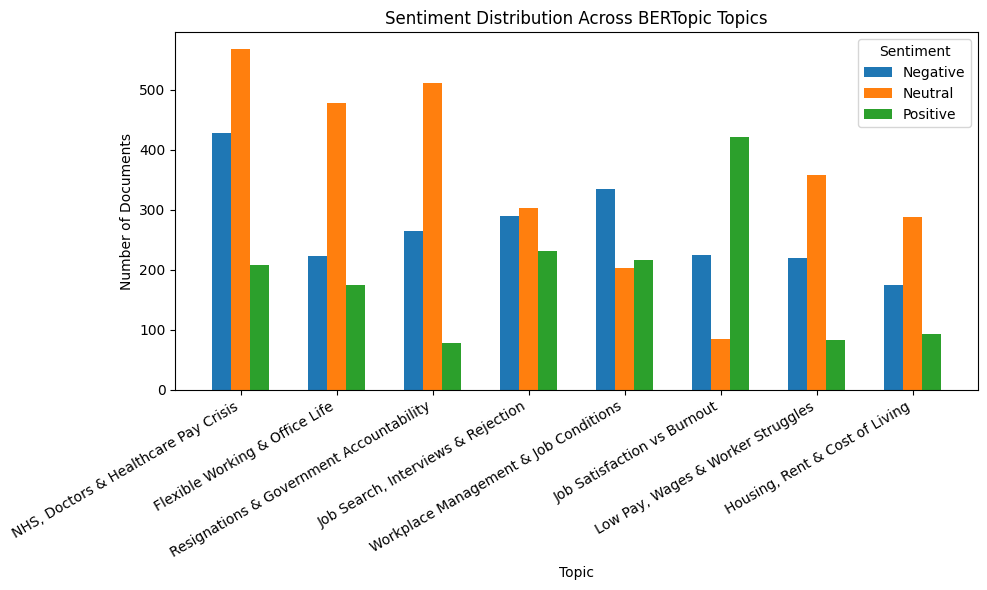

In [38]:
data = data.reset_index(drop=True)

data["topic_id"] = topics
data["topic_label"] = data["topic_id"].map(topic_labels)

data_plot = data[data["topic_id"] != -1].copy()

sent_counts = (
    data_plot.groupby(["topic_label", "sentiment"])
             .size()
             .reset_index(name="count")
)

sent_pivot = sent_counts.pivot(
    index="topic_label",
    columns="sentiment",
    values="count"
).fillna(0)

topic_order_df = (
    data_plot[["topic_id", "topic_label"]]
    .drop_duplicates()
    .sort_values("topic_id")
)

topic_order_df = topic_order_df.dropna(subset=['topic_label'])
sent_pivot = sent_pivot.loc[topic_order_df["topic_label"]]

topics_list = sent_pivot.index.tolist()
sentiments = sent_pivot.columns.tolist()

x = np.arange(len(topics_list))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, s in enumerate(sentiments):
    ax.bar(
        x + (i - (len(sentiments)-1)/2) * width,
        sent_pivot[s].values,
        width,
        label=s
    )

ax.set_xticks(x)
ax.set_xticklabels(topics_list, rotation=30, ha="right")
ax.set_ylabel("Number of Documents")
ax.set_xlabel("Topic")
ax.set_title("Sentiment Distribution Across BERTopic Topics")
ax.legend(title="Sentiment")

plt.tight_layout()
plt.show()

##### **Creating a JSON File to get the topic**

In [39]:
bertopic_json = {}

for topic_id, words in topic_words.items():

    if topic_id not in data["topic_id"].values:
        continue
    topic_name = topic_labels.get(topic_id, f"Topic {topic_id}")
    doc_count = int((data["topic_id"] == topic_id).sum())
    coherence_score = topic_coherence.get(topic_id)
    sentiment_dist = (
        data[data["topic_id"] == topic_id]["sentiment"]
        .value_counts()
        .to_dict()
    )
    bertopic_json[f"topic_{topic_id}"] = {
        "topic_id": int(topic_id),
        "topic_label": topic_name,
        "top_words": words[:10],
        "document_count": doc_count,
        "coherence_score": coherence_score,
        "sentiment_distribution": sentiment_dist
    }

final_json = {
    "Bertopic": bertopic_json
}

print(final_json)

{'Bertopic': {'topic_-1': {'topic_id': -1, 'topic_label': 'General Public Discussion & Mixed Opinions', 'top_words': ['people', 'really', 'just', 'work', 'https', 'like', 'job', 'www', 'bad', 'gt'], 'document_count': 4635, 'coherence_score': np.float64(0.39123887154674813), 'sentiment_distribution': {'Neutral': 1914, 'Negative': 1680, 'Positive': 1041}}, 'topic_0': {'topic_id': 0, 'topic_label': 'NHS, Doctors & Healthcare Pay Crisis', 'top_words': ['nhs', 'doctors', 'gp', 'care', 'nurses', 'pay', 'underpaid', 'staff', 'gps', 'patients'], 'document_count': 1203, 'coherence_score': np.float64(0.4787190813460652), 'sentiment_distribution': {'Neutral': 567, 'Negative': 428, 'Positive': 208}}, 'topic_1': {'topic_id': 1, 'topic_label': 'Flexible Working & Office Life', 'top_words': ['working', 'flexible', 'office', 'flexible working', 'home', 'work', 'wfh', 'days', 'working home', 'week'], 'document_count': 874, 'coherence_score': np.float64(0.6845968068109697), 'sentiment_distribution': {'N

#### **Collapse Both LDA and Bertopic result for later exploration**

In [40]:
data_final =  {
    "2021": {
        "LDA": final_lda_json,
        "Bertopic": final_json
    }
}

print(data_final)

{'2021': {'LDA': {'LDA_Sentiment_Summary': {'General Frustration & Unreasonable Situations': {'Negative': 1146, 'Neutral': 1754, 'Positive': 380}, 'Jobs, Pay & Working Hours': {'Negative': 2512, 'Neutral': 3887, 'Positive': 1790}, 'UK Politics': {'Negative': 677, 'Neutral': 1582, 'Positive': 232}, 'Work-Related Feelings & Stress': {'Negative': 3340, 'Neutral': 1933, 'Positive': 2061}}}, 'Bertopic': {'Bertopic': {'topic_-1': {'topic_id': -1, 'topic_label': 'General Public Discussion & Mixed Opinions', 'top_words': ['people', 'really', 'just', 'work', 'https', 'like', 'job', 'www', 'bad', 'gt'], 'document_count': 4635, 'coherence_score': np.float64(0.39123887154674813), 'sentiment_distribution': {'Neutral': 1914, 'Negative': 1680, 'Positive': 1041}}, 'topic_0': {'topic_id': 0, 'topic_label': 'NHS, Doctors & Healthcare Pay Crisis', 'top_words': ['nhs', 'doctors', 'gp', 'care', 'nurses', 'pay', 'underpaid', 'staff', 'gps', 'patients'], 'document_count': 1203, 'coherence_score': np.float64(

In [42]:
with open("topic_model_master_2021.json", "w", encoding="utf-8") as f:
    json.dump(data_final, f, indent=4, ensure_ascii=False)

print("Master JSON saved as topic_model_master_2021.json")

Master JSON saved as topic_model_master_2021.json
